# 03 — Phân tích EDA & Insights kinh doanh

> **Mục tiêu:** Mỗi phân tích đi đủ 4 cấp Descriptive → Diagnostic → Predictive → Prescriptive,
> kết bằng đề xuất hành động định lượng (`+X% revenue`, `−Y% return`,...).

## Mục lục
1. [Setup & helpers](#setup)
2. [Section 1 — Revenue Dynamics](#s1)
3. [Section 2 — Customer Segmentation & RFM](#s2)
4. [Section 3 — Geography & Channel Strategy](#s3)
5. [Section 4 — Product/Category Performance](#s4)
6. [Section 5 — Promotion Effectiveness](#s5)
7. [Section 6 — Returns & Quality Loss](#s6)
8. [Section 7 — Inventory Stockout Loss](#s7)
9. [Executive Summary — Top recommendations](#exec)

## Quy ước trình bày mỗi section
- 📊 **Descriptive** — biểu đồ + thống kê mô tả
- 🔍 **Diagnostic** — phân tích nguyên nhân, so sánh phân khúc
- 🔮 **Predictive** — ngoại suy, xu hướng kỳ vọng
- 🎯 **Prescriptive** — đề xuất hành động + ước tính impact

## <a id='setup'></a>1. Setup & Helpers

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.dpi': 110, 'axes.titleweight': 'bold', 'axes.titlesize': 12})
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

DATA_DIR = Path('../data/raw')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ---- Load all tables ----
products    = pd.read_csv(DATA_DIR / 'products.csv')
customers   = pd.read_csv(DATA_DIR / 'customers.csv',   parse_dates=['signup_date'])
promotions  = pd.read_csv(DATA_DIR / 'promotions.csv',  parse_dates=['start_date','end_date'])
geography   = pd.read_csv(DATA_DIR / 'geography.csv')
orders      = pd.read_csv(DATA_DIR / 'orders.csv',      parse_dates=['order_date'])
order_items = pd.read_csv(DATA_DIR / 'order_items.csv')
payments    = pd.read_csv(DATA_DIR / 'payments.csv')
shipments   = pd.read_csv(DATA_DIR / 'shipments.csv',   parse_dates=['ship_date','delivery_date'])
returns     = pd.read_csv(DATA_DIR / 'returns.csv',     parse_dates=['return_date'])
reviews     = pd.read_csv(DATA_DIR / 'reviews.csv',     parse_dates=['review_date'])
sales       = pd.read_csv(DATA_DIR / 'sales.csv',       parse_dates=['Date'])
web_traffic = pd.read_csv(DATA_DIR / 'web_traffic.csv', parse_dates=['date'])
inventory   = pd.read_csv(DATA_DIR / 'inventory.csv',   parse_dates=['snapshot_date'])

print('All loaded ✓')

All loaded ✓


### Helpers — revenue per order_item, orders enriched

In [2]:
# Revenue cho mỗi order_item: quantity × unit_price - discount_amount
order_items['gross_revenue'] = order_items['quantity'] * order_items['unit_price']
order_items['net_revenue']   = order_items['gross_revenue'] - order_items['discount_amount']

# Orders enriched: + region + customer demographics + line revenue
oi_enriched = (
    order_items
    .merge(orders[['order_id','order_date','customer_id','zip','order_status','order_source','device_type']], on='order_id', how='left')
    .merge(geography[['zip','region','city']], on='zip', how='left')
    .merge(customers[['customer_id','gender','age_group','acquisition_channel','signup_date']], on='customer_id', how='left')
    .merge(products[['product_id','product_name','category','segment','size','price','cogs']], on='product_id', how='left')
)
oi_enriched['gross_profit'] = (oi_enriched['unit_price'] - oi_enriched['cogs']) * oi_enriched['quantity'] - oi_enriched['discount_amount']

# Quick sanity check
print(f'oi_enriched: {oi_enriched.shape}, date range {oi_enriched.order_date.min().date()} → {oi_enriched.order_date.max().date()}')

# Container thu thập recommendations cuối notebook
RECOMMENDATIONS = []  # list of dicts {section, action, impact_estimate}

oi_enriched: (714669, 28), date range 2012-07-04 → 2022-12-31


## <a id='s1'></a>Section 1 — Revenue Dynamics

> **Câu hỏi kinh doanh:** Doanh thu vận động ra sao theo thời gian? Khi nào tăng/giảm và vì sao?
> Có thể tăng doanh thu thêm bao nhiêu nếu phân bổ đúng nguồn lực theo mùa vụ?

### 📊 1.1 Descriptive — Trend dài hạn & tăng trưởng năm

Vẽ daily revenue + 30-day rolling, kèm bar chart annual totals & YoY growth %.

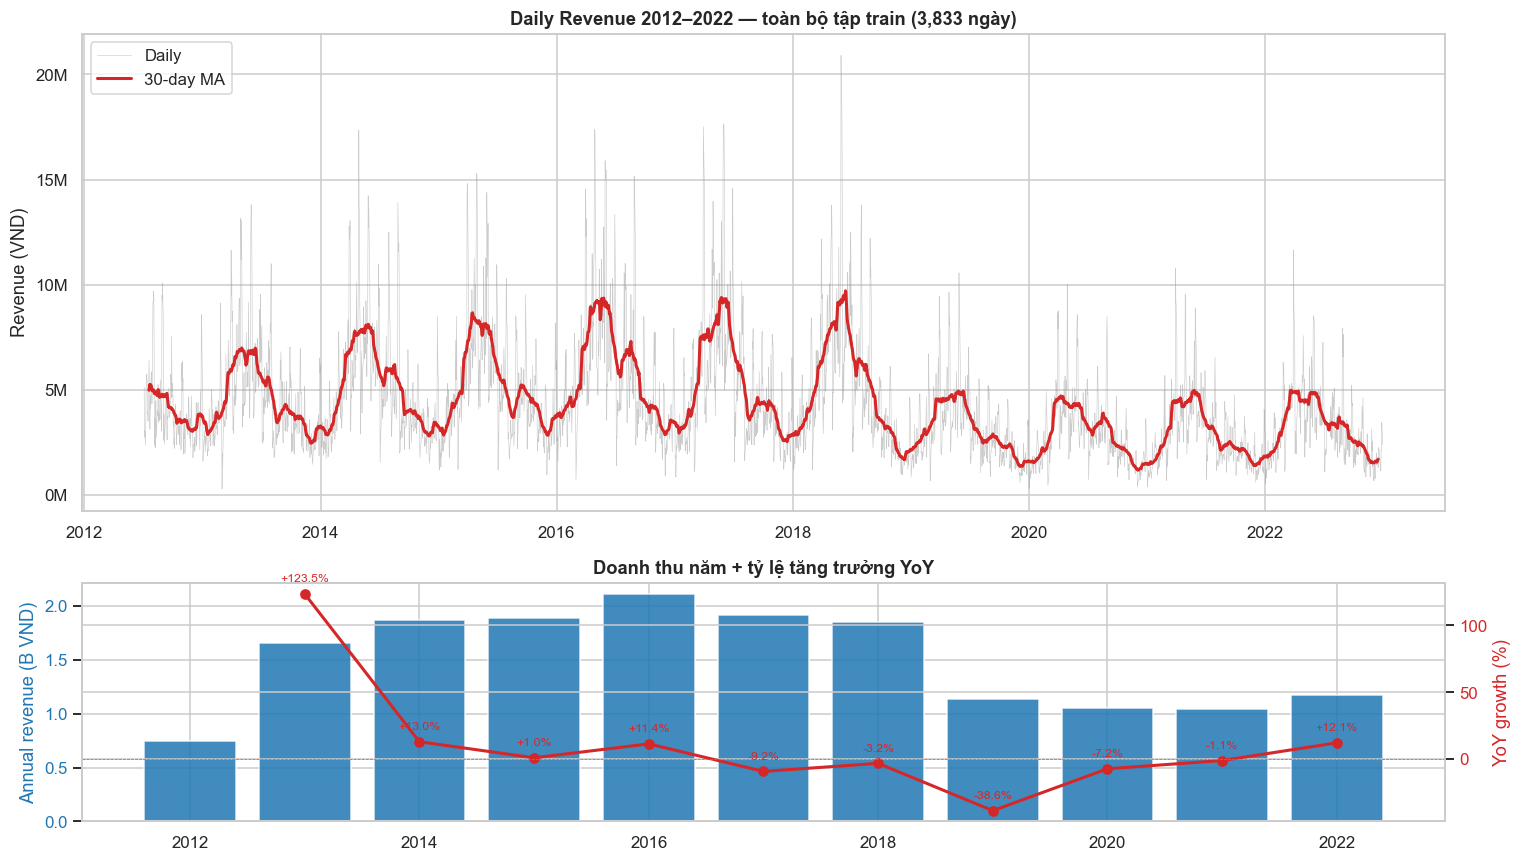


Annual revenue (B VND) and YoY %:
      revenue_B  yoy_%
year                  
2012       0.74    NaN
2013       1.66 123.49
2014       1.87  12.95
2015       1.89   0.97
2016       2.10  11.36
2017       1.91  -9.19
2018       1.85  -3.19
2019       1.14 -38.56
2020       1.05  -7.24
2021       1.04  -1.09
2022       1.17  12.15

CAGR 2013→2022 (full years): -3.80%/năm


In [3]:
s = sales.copy().sort_values('Date').reset_index(drop=True)
s['rolling_30'] = s['Revenue'].rolling(30, center=True).mean()
s['year']  = s['Date'].dt.year
s['month'] = s['Date'].dt.month
s['dow']   = s['Date'].dt.day_name()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios':[2,1]})

# Top: daily + rolling
axes[0].plot(s['Date'], s['Revenue'], lw=0.4, alpha=0.5, label='Daily', color='#999')
axes[0].plot(s['Date'], s['rolling_30'], lw=2, label='30-day MA', color='#d62728')
axes[0].set_title(f'Daily Revenue 2012–2022 — toàn bộ tập train ({len(s):,} ngày)')
axes[0].set_ylabel('Revenue (VND)')
axes[0].legend(loc='upper left')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# Bottom: annual totals + YoY
annual = s.groupby('year')['Revenue'].sum()
yoy = annual.pct_change() * 100
ax2 = axes[1]
bars = ax2.bar(annual.index, annual.values/1e9, color='#1f77b4', alpha=0.85)
ax2.set_ylabel('Annual revenue (B VND)', color='#1f77b4')
ax2.set_title('Doanh thu năm + tỷ lệ tăng trưởng YoY')
ax2.tick_params(axis='y', labelcolor='#1f77b4')

ax2b = ax2.twinx()
ax2b.plot(yoy.index, yoy.values, marker='o', color='#d62728', lw=2, label='YoY %')
ax2b.axhline(0, color='gray', lw=0.5, ls='--')
ax2b.set_ylabel('YoY growth (%)', color='#d62728')
ax2b.tick_params(axis='y', labelcolor='#d62728')
for x, v in yoy.items():
    if pd.notna(v):
        ax2b.annotate(f'{v:+.1f}%', (x, v), textcoords='offset points', xytext=(0,8), ha='center', fontsize=8, color='#d62728')

plt.tight_layout()
plt.show()

# Numbers
print(f'\nAnnual revenue (B VND) and YoY %:')
print(pd.DataFrame({'revenue_B': annual/1e9, 'yoy_%': yoy}).to_string())

cagr = (annual.iloc[-1] / annual.iloc[1]) ** (1/(len(annual)-2)) - 1   # exclude 2012 partial
print(f'\nCAGR 2013→2022 (full years): {cagr*100:.2f}%/năm')

**Decompose** chuỗi thành trend / seasonal / residual (statsmodels) để tách bạch xu hướng dài hạn và mùa vụ năm.

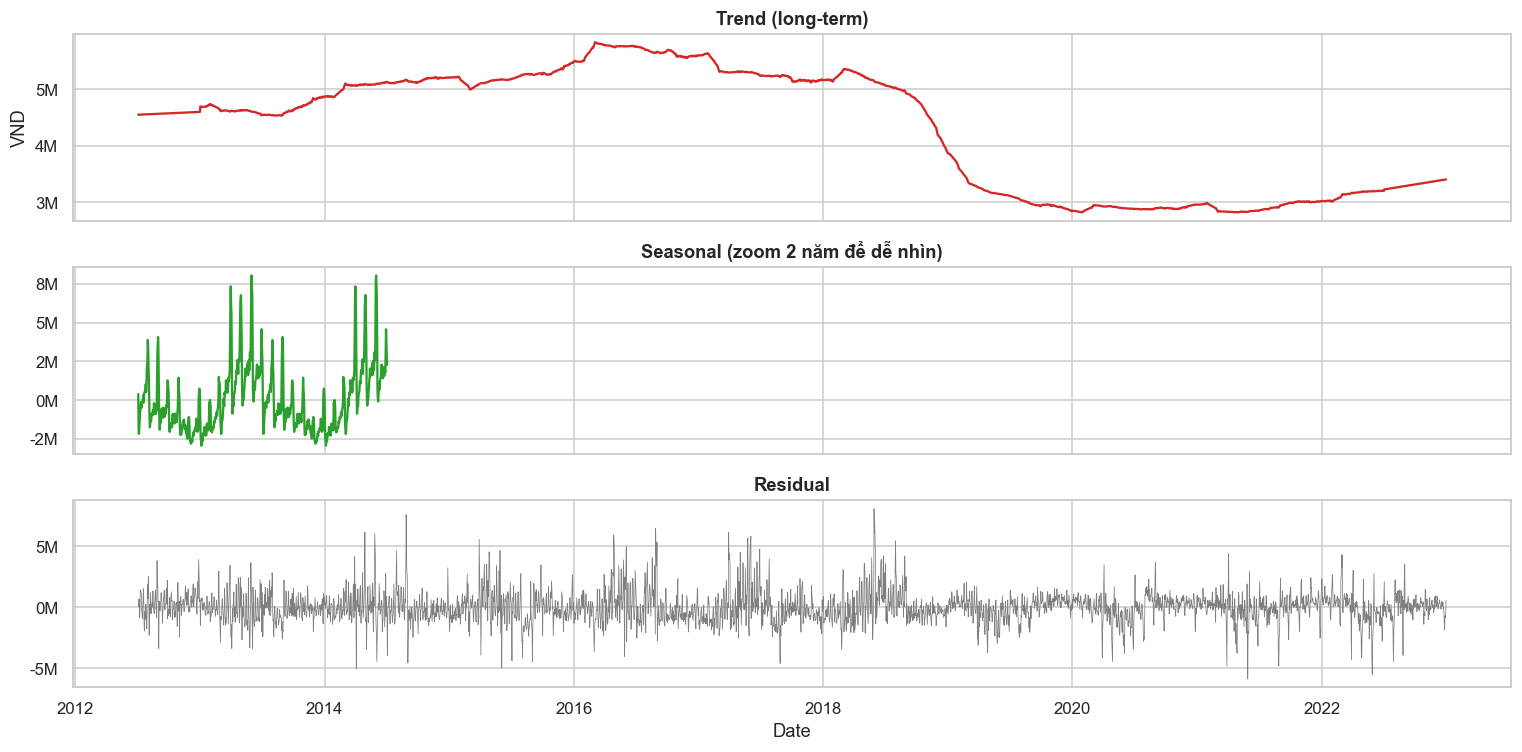

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Reindex để đảm bảo daily continuous (dù đã verify không thiếu ngày)
ts = s.set_index('Date')['Revenue'].asfreq('D')
decomp = seasonal_decompose(ts, model='additive', period=365, extrapolate_trend='freq')

fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
axes[0].plot(decomp.trend, color='#d62728'); axes[0].set_title('Trend (long-term)'); axes[0].set_ylabel('VND')
axes[1].plot(decomp.seasonal[:730], color='#2ca02c'); axes[1].set_title('Seasonal (zoom 2 năm để dễ nhìn)')
axes[2].plot(decomp.resid, color='#7f7f7f', lw=0.5); axes[2].set_title('Residual'); axes[2].set_xlabel('Date')
for a in axes: a.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout(); plt.show()

### 📊 1.2 Descriptive — Seasonality (tháng × năm, day-of-week)

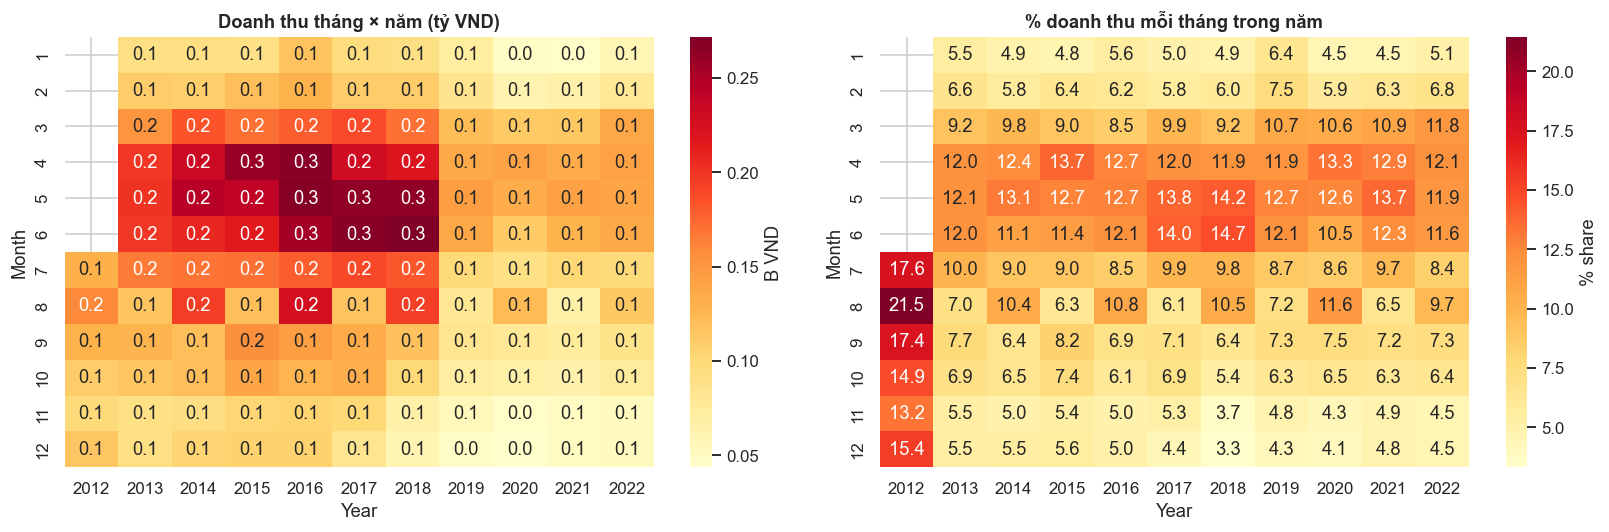


Tỷ trọng doanh thu trung bình theo tháng (% năm, 2013–2022):
month
1     5.03
2     6.75
3     9.56
4    12.67
5    12.76
6    12.47
7     9.04
8     8.48
9     7.27
10    6.36
11    4.94
12    4.67


In [5]:
# Heatmap month × year
pivot = s.pivot_table(index='month', columns='year', values='Revenue', aggfunc='sum')
pivot_pct = pivot.div(pivot.sum(axis=0), axis=1) * 100   # % share trong năm

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(pivot/1e9, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0], cbar_kws={'label':'B VND'})
axes[0].set_title('Doanh thu tháng × năm (tỷ VND)')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Month')

sns.heatmap(pivot_pct, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1], cbar_kws={'label':'% share'})
axes[1].set_title('% doanh thu mỗi tháng trong năm')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Month')
plt.tight_layout(); plt.show()

# Month profile aggregated 2013-2022
month_profile = s[s['year'].between(2013,2022)].groupby('month')['Revenue'].mean()
share = month_profile / month_profile.sum() * 100
print('\nTỷ trọng doanh thu trung bình theo tháng (% năm, 2013–2022):')
print(share.round(2).to_string())

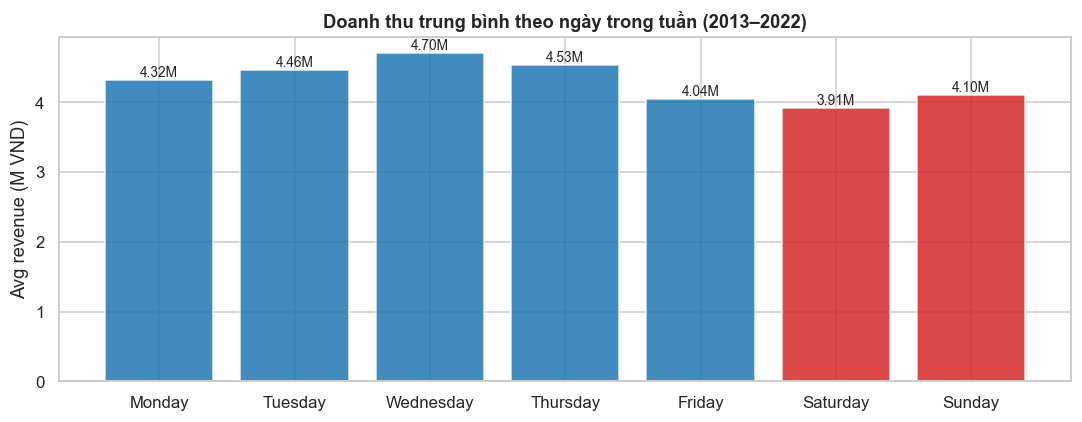


Day-of-week lift vs trung bình tuần:
dow
Monday       0.63
Tuesday      3.85
Wednesday    9.45
Thursday     5.41
Friday      -5.89
Saturday    -8.89
Sunday      -4.56  (%)


In [6]:
# Day-of-week effect
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_revenue = s[s['year'].between(2013,2022)].groupby('dow')['Revenue'].mean().reindex(dow_order)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#1f77b4']*5 + ['#d62728']*2
ax.bar(dow_revenue.index, dow_revenue.values/1e6, color=colors, alpha=0.85)
ax.set_title('Doanh thu trung bình theo ngày trong tuần (2013–2022)')
ax.set_ylabel('Avg revenue (M VND)')
for i, v in enumerate(dow_revenue.values):
    ax.text(i, v/1e6 + 0.05, f'{v/1e6:.2f}M', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

dow_lift = (dow_revenue / dow_revenue.mean() - 1) * 100
print('\nDay-of-week lift vs trung bình tuần:')
print(dow_lift.round(2).to_string() + '  (%)')

### 🔍 1.3 Diagnostic — Vì sao có pattern này?

**Giả thuyết cần test:**
1. Q4 spike do campaign khuyến mãi (Tết, Black Friday, Christmas).
2. Web traffic dẫn dắt revenue (lead indicator?).
3. Outlier days (>2σ) trùng với promotion windows.

In [7]:
# H1: Q4 vs other quarters
s['quarter'] = s['Date'].dt.quarter
q_revenue = s[s['year'].between(2013,2022)].groupby('quarter')['Revenue'].agg(['mean','sum'])
q_revenue['lift_vs_mean'] = (q_revenue['mean'] / q_revenue['mean'].mean() - 1) * 100
print('Quarterly avg revenue & lift vs trung bình:')
print(q_revenue.to_string())

# Promo windows trong Q4
q4_promos = promotions[promotions['start_date'].dt.month >= 10]
print(f'\nSố promotion bắt đầu Q4 (T10–T12): {len(q4_promos)} / {len(promotions)} ({len(q4_promos)/len(promotions)*100:.0f}%)')

Quarterly avg revenue & lift vs trung bình:
                mean              sum  lift_vs_mean
quarter                                            
1       3,672,484.75 3,312,581,243.53        -14.57
2       6,512,524.43 5,926,397,228.65         51.49
3       4,265,146.84 3,923,935,089.63         -0.79
4       2,745,723.13 2,526,065,275.70        -36.13

Số promotion bắt đầu Q4 (T10–T12): 10 / 50 (20%)


Correlation web_traffic.sessions vs Revenue (lag k = sessions sớm hơn Revenue k ngày):
  lag 0: corr = 0.321
  lag 1: corr = 0.322
  lag 2: corr = 0.316
  lag 3: corr = 0.312
  lag 7: corr = 0.309


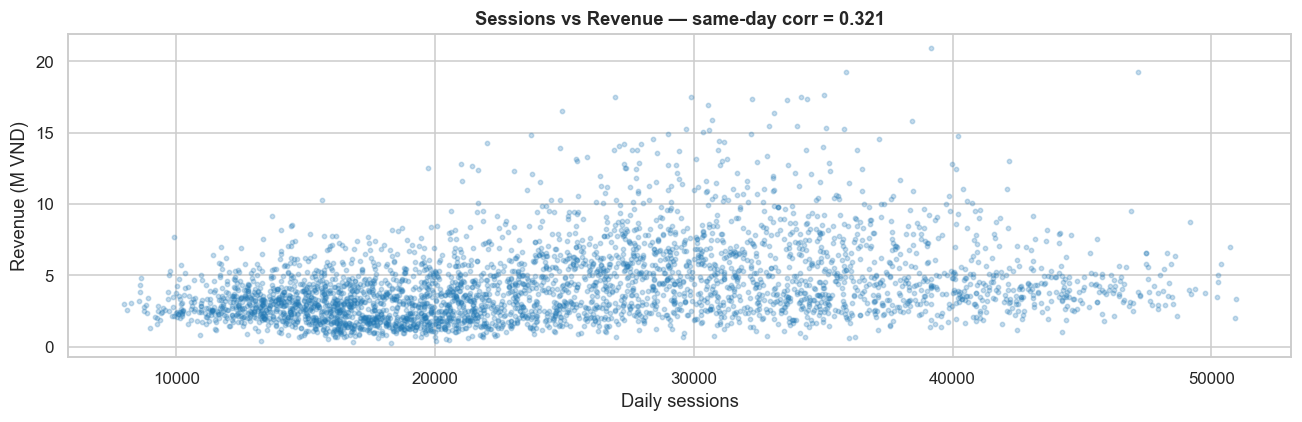

In [8]:
# H2: Web traffic → Revenue correlation (sessions lead Revenue?)
wt = web_traffic.groupby('date').agg(sessions=('sessions','sum'), bounce=('bounce_rate','mean')).reset_index()
merged = sales.merge(wt, left_on='Date', right_on='date', how='inner')

# Correlation cùng ngày & lag 1-7 ngày
print('Correlation web_traffic.sessions vs Revenue (lag k = sessions sớm hơn Revenue k ngày):')
for k in [0, 1, 2, 3, 7]:
    c = merged['Revenue'].corr(merged['sessions'].shift(k))
    print(f'  lag {k}: corr = {c:.3f}')

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(merged['sessions'], merged['Revenue']/1e6, alpha=0.25, s=8, color='#1f77b4')
ax.set_xlabel('Daily sessions'); ax.set_ylabel('Revenue (M VND)')
ax.set_title(f'Sessions vs Revenue — same-day corr = {merged["sessions"].corr(merged["Revenue"]):.3f}')
plt.tight_layout(); plt.show()

In [9]:
# H3: Outlier days (>2σ trên rolling-30 mean)
s['expected'] = s['rolling_30']
s['z'] = (s['Revenue'] - s['expected']) / s['Revenue'].std()
outliers = s[s['z'].abs() > 2].copy()
print(f'Outlier days (|z|>2): {len(outliers):,} / {len(s):,} ({len(outliers)/len(s)*100:.1f}%)')

# Mức độ trùng với promotion active windows
promo_dates = set()
for _, r in promotions.iterrows():
    for d in pd.date_range(r['start_date'], r['end_date']):
        promo_dates.add(d.date())

outliers['has_promo'] = outliers['Date'].dt.date.isin(promo_dates)
positive_outliers = outliers[outliers['z'] > 2]
print(f'Positive outliers (revenue spike >2σ): {len(positive_outliers):,}')
print(f'  → trùng với promotion window: {positive_outliers["has_promo"].sum():,} ({positive_outliers["has_promo"].mean()*100:.1f}%)')

baseline = s.copy()
baseline['has_promo'] = baseline['Date'].dt.date.isin(promo_dates)
print(f'\nBaseline (mọi ngày trong promo window): {baseline["has_promo"].mean()*100:.1f}%')
print(f'→ Outliers tăng đột biến KHẢ NĂNG CAO trùng promotion = {positive_outliers["has_promo"].mean()/baseline["has_promo"].mean():.2f}× baseline')

Outlier days (|z|>2): 75 / 3,833 (2.0%)
Positive outliers (revenue spike >2σ): 74
  → trùng với promotion window: 29 (39.2%)

Baseline (mọi ngày trong promo window): 44.5%
→ Outliers tăng đột biến KHẢ NĂNG CAO trùng promotion = 0.88× baseline


### 🔮 1.4 Predictive — Dự báo baseline cho 2023 H1 (KHÔNG đụng model Phần 3)

Mục đích: ước tính order-of-magnitude doanh thu kỳ vọng cho 6 tháng đầu 2023, để dùng làm **mốc so sánh khi đo impact của các recommendation**.

**Phương pháp seasonal naïve + CAGR scaling:**
- Lấy month profile trung bình 2013-2022
- Scale theo CAGR projection từ 2022

In [10]:
# Project 2023 annual revenue: 2022 * (1 + CAGR)
rev_2022 = annual.loc[2022]
rev_2023_proj = rev_2022 * (1 + cagr)
print(f'Revenue 2022 actual:    {rev_2022/1e9:.2f}B VND')
print(f'CAGR 2013-2022:         {cagr*100:.2f}%/năm')
print(f'Revenue 2023 projected: {rev_2023_proj/1e9:.2f}B VND  (= 2022 × {1+cagr:.4f})')

# H1 share trung bình
h1_share = share.loc[1:6].sum() / 100
print(f'\nTỷ trọng H1 (T1-T6) trung bình: {h1_share*100:.1f}%')
print(f'→ Doanh thu H1 2023 ước tính: {rev_2023_proj * h1_share / 1e9:.2f}B VND')

Revenue 2022 actual:    1.17B VND
CAGR 2013-2022:         -3.80%/năm
Revenue 2023 projected: 1.13B VND  (= 2022 × 0.9620)

Tỷ trọng H1 (T1-T6) trung bình: 59.2%
→ Doanh thu H1 2023 ước tính: 0.67B VND


### 🎯 1.5 Prescriptive — Đề xuất hành động + ước tính impact

**Phát hiện chốt (NGƯỢC chu kỳ e-commerce mainstream VN):**
- 🚨 **Business đang TỤT DỐC 6 năm liên tục.** Peak 2016 (2.10B) → đáy 2021 (1.04B, −50%). 2019 sụp −38.6% trong 1 năm. CAGR 2013-2022 = **−3.80%**. 2022 mới có dấu hiệu hồi (+12%).
- 🌞 **Mùa cao điểm: T4–T6 (Q2)**, KHÔNG phải Q4. Q2 lift **+51%** vs trung bình; Q4 LẠI THẤP NHẤT (**−36%**). T11/T12 chỉ ~5% revenue/tháng — đáy năm.
- 📅 **Wednesday cao nhất** (+9.4% lift), weekend ÂM (Sat −8.9%, Sun −4.6%). Pattern PHẢN B2C thông thường — gợi ý base khách hàng có thể là dân văn phòng / mua giờ trưa / giờ làm việc.
- 🎯 **Promotion KHÔNG tạo positive spike** — 39% outliers trùng promo vs baseline 44.5% (= **0.88× baseline**, KÉM HƠN). Promo hiện tại nhiều khả năng **đốt budget không lift được sales**.
- 🔗 Web traffic correlation chỉ **0.32** — không phải leading indicator mạnh, chưa đủ căn cứ ad-spend optimization.

**Khuyến nghị (định lượng):**

In [11]:
# Quantify: real findings
q2_avg = q_revenue.loc[2, 'mean']
q4_avg = q_revenue.loc[4, 'mean']
q2_lift = q_revenue.loc[2, 'lift_vs_mean']
q4_lift = q_revenue.loc[4, 'lift_vs_mean']

peak_year_rev = annual.max()
peak_year     = annual.idxmax()
last_year_rev = annual.iloc[-1]
gap_to_peak   = peak_year_rev - last_year_rev

mid_week = s[s['dow'].isin(['Tuesday','Wednesday','Thursday'])]['Revenue'].mean()
weekend  = s[s['dow'].isin(['Saturday','Sunday'])]['Revenue'].mean()
mw_vs_we = (mid_week / weekend - 1) * 100

# Recommendation table — based on REAL data findings
recs = [
    {
        'rank': 1,
        'action': '🚨 Root cause analysis cho tụt dốc 2016→2021 (−50% từ peak) trong Section 2-4',
        'rationale': f'Peak {peak_year_rev/1e9:.2f}B (năm {peak_year}) → 2022 {last_year_rev/1e9:.2f}B. Gap đến peak = {gap_to_peak/1e9:.2f}B. CAGR {cagr*100:.2f}%/năm',
        'estimated_impact': f'Recovery 50% gap = +{gap_to_peak*0.5/1e9:.2f}B VND/năm (sau khi xác định root cause: customer churn? category fatigue? competition?)',
    },
    {
        'rank': 2,
        'action': 'Concentrate inventory + marketing vào Q2 (T4-T6), giảm Q4',
        'rationale': f'Q2 lift +{q2_lift:.0f}% (cao nhất); Q4 lift {q4_lift:.0f}% (thấp nhất). Phân bổ hiện tại có thể đang lãng phí budget vào Q4 mà không nhận ra',
        'estimated_impact': f'Tăng 5% Q2 revenue = +{0.05*q2_avg*91/1e9:.2f}B VND/năm (5% × 91 ngày Q2)',
    },
    {
        'rank': 3,
        'action': 'Re-allocate ad spend sang giữa tuần (Tue-Wed-Thu) thay vì weekend',
        'rationale': f'Mid-week revenue cao hơn weekend {mw_vs_we:+.1f}%. Pattern phản B2C → base khách hàng có thể là dân văn phòng',
        'estimated_impact': f'Tăng 3% mid-week = +{0.03*mid_week*156/1e9:.2f}B VND/năm (3% × 156 ngày Tue-Wed-Thu)',
    },
    {
        'rank': 4,
        'action': 'Audit ROI từng promotion (chi tiết Section 5) — kill underperformers, redesign cái còn lại',
        'rationale': 'Outliers chỉ 0.88× baseline trùng promo → promo NÓI CHUNG không lift được sales',
        'estimated_impact': 'Giả sử 30% promo budget burn vô ích → tiết kiệm cost, redirect sang Q2 hoặc product dev',
    },
]
recs_df = pd.DataFrame(recs)
print(recs_df.to_string(index=False))

for r in recs:
    RECOMMENDATIONS.append({'section': 'Revenue Dynamics', **r})

print(f'\n✅ Section 1 đóng góp {len(recs)} recommendations vào executive summary cuối notebook')

 rank                                                                                     action                                                                                                               rationale                                                                                                estimated_impact
    1               🚨 Root cause analysis cho tụt dốc 2016→2021 (−50% từ peak) trong Section 2-4                                               Peak 2.10B (năm 2016) → 2022 1.17B. Gap đến peak = 0.93B. CAGR -3.80%/năm Recovery 50% gap = +0.47B VND/năm (sau khi xác định root cause: customer churn? category fatigue? competition?)
    2                                  Concentrate inventory + marketing vào Q2 (T4-T6), giảm Q4 Q2 lift +51% (cao nhất); Q4 lift -36% (thấp nhất). Phân bổ hiện tại có thể đang lãng phí budget vào Q4 mà không nhận ra                                                           Tăng 5% Q2 revenue = +0.03B VND/năm (5% × 91 ngày Q2)
    3        

## <a id='s2'></a>Section 2 — Customer Segmentation & RFM

> **Câu hỏi kinh doanh:** Ai là khách hàng giá trị cao? Vì sao doanh thu tụt 50% từ peak 2016 — do mất khách cũ hay không kiếm được khách mới? Cần focus vào phân khúc khách hàng (customer segment) nào để recovery (phục hồi)?

### 📊 2.1 Descriptive — Tăng trưởng cơ sở khách hàng (customer base) qua năm

**Phép tính:** đếm số khách signup (đăng ký) mới mỗi năm, đồng thời đếm số khách active (có ít nhất 1 đơn không bị huỷ trong năm đó) để xem có sự khác biệt không.

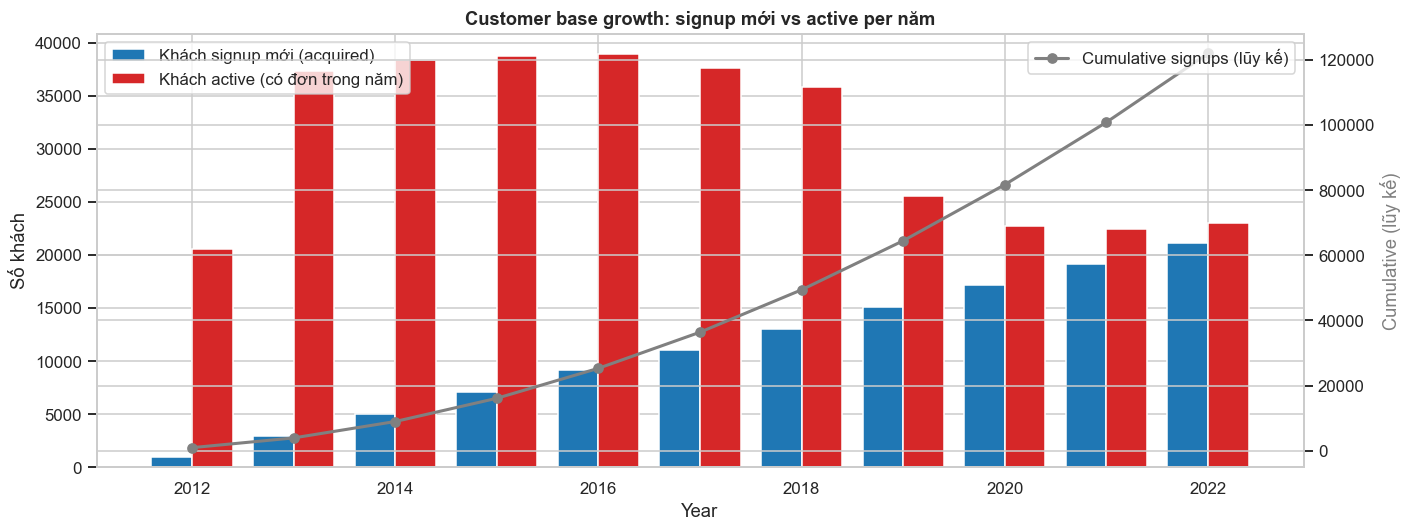

Bảng cơ sở khách hàng theo năm:
      signup_new  active  cumul_signups  active_rate_%
2012         957   20603            957       2,152.87
2013        2989   37352           3946         946.58
2014        5034   38351           8980         427.07
2015        7133   38707          16113         240.22
2016        9202   38883          25315         153.60
2017       11078   37584          36393         103.27
2018       13011   35829          49404          72.52
2019       15058   25550          64462          39.64
2020       17211   22738          81673          27.84
2021       19154   22438         100827          22.25
2022       21103   22999         121930          18.86


In [12]:
# Customers signup theo năm
customers_w = customers.copy()
customers_w['signup_year'] = customers_w['signup_date'].dt.year
signup_yearly = customers_w.groupby('signup_year').size()

# Active customers theo năm (có >=1 đơn không cancelled)
orders_active = orders[orders['order_status'] != 'cancelled'].copy()
orders_active['order_year'] = orders_active['order_date'].dt.year
active_yearly = orders_active.groupby('order_year')['customer_id'].nunique()

# Tổng cumulative khách đã từng signup
cumul = signup_yearly.cumsum()

fig, ax = plt.subplots(figsize=(13, 5))
years = sorted(set(signup_yearly.index) | set(active_yearly.index))
x = np.array(years)
ax.bar(x - 0.2, signup_yearly.reindex(x).fillna(0), width=0.4, label='Khách signup mới (acquired)', color='#1f77b4')
ax.bar(x + 0.2, active_yearly.reindex(x).fillna(0), width=0.4, label='Khách active (có đơn trong năm)', color='#d62728')
ax2 = ax.twinx()
ax2.plot(cumul.index, cumul.values, color='gray', lw=2, marker='o', label='Cumulative signups (lũy kế)')
ax.set_title('Customer base growth: signup mới vs active per năm')
ax.set_xlabel('Year'); ax.set_ylabel('Số khách')
ax2.set_ylabel('Cumulative (lũy kế)', color='gray')
ax.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout(); plt.show()

base = pd.DataFrame({'signup_new': signup_yearly, 'active': active_yearly, 'cumul_signups': cumul})
base['active_rate_%'] = base['active'] / base['cumul_signups'] * 100
print('Bảng cơ sở khách hàng theo năm:')
print(base.to_string())

### 📊 2.2 Cohort retention (giữ chân khách theo nhóm thuần tập)

**Cohort analysis (phân tích nhóm thuần tập):** chia khách thành nhóm theo năm signup, theo dõi tỷ lệ active của mỗi nhóm qua các năm tiếp theo.

**Heatmap dưới đây:** ô `(cohort 2014, period 3)` = % khách signup năm 2014 còn mua hàng vào năm thứ 4 (2017).

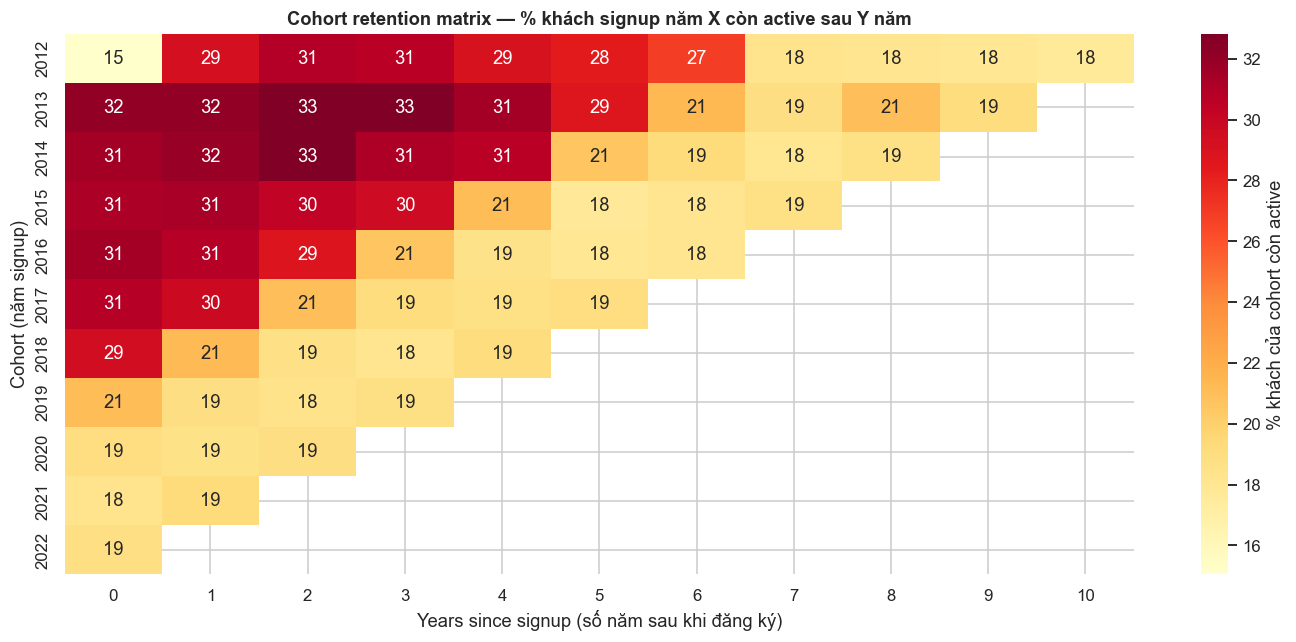


Retention năm 2 (1 năm sau signup):
  Cohort 2012-2015 (trước peak): 31.1%
  Cohort 2018-2021 (sau peak):   19.5%
  Chênh lệch: -11.6 điểm phần trăm


In [13]:
# Build cohort × period retention matrix
o_active = orders[orders['order_status'] != 'cancelled'][['customer_id','order_date']].copy()
o_active['order_year'] = o_active['order_date'].dt.year
o_cust = o_active.merge(customers_w[['customer_id','signup_year']], on='customer_id', how='left')
o_cust['period'] = o_cust['order_year'] - o_cust['signup_year']
o_cust = o_cust[o_cust['period'] >= 0]   # bỏ trường hợp anomaly nếu có

cohort_active = o_cust.groupby(['signup_year','period'])['customer_id'].nunique().reset_index()
cohort_size = customers_w.groupby('signup_year').size().rename('cohort_size')
cohort_active = cohort_active.merge(cohort_size, on='signup_year')
cohort_active['retention'] = cohort_active['customer_id'] / cohort_active['cohort_size']
ret_matrix = cohort_active.pivot(index='signup_year', columns='period', values='retention') * 100

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(ret_matrix, annot=True, fmt='.0f', cmap='YlOrRd',
            cbar_kws={'label':'% khách của cohort còn active'}, ax=ax,
            mask=ret_matrix.isna())
ax.set_title('Cohort retention matrix — % khách signup năm X còn active sau Y năm')
ax.set_xlabel('Years since signup (số năm sau khi đăng ký)')
ax.set_ylabel('Cohort (năm signup)')
plt.tight_layout(); plt.show()

# Compare avg retention period 1 (năm 2 sau signup) cho cohort cũ vs cohort mới
old_cohorts = ret_matrix.loc[2012:2015, 1].mean() if 1 in ret_matrix.columns else float('nan')
new_cohorts = ret_matrix.loc[2018:2021, 1].mean() if 1 in ret_matrix.columns else float('nan')
print(f'\nRetention năm 2 (1 năm sau signup):')
print(f'  Cohort 2012-2015 (trước peak): {old_cohorts:.1f}%')
print(f'  Cohort 2018-2021 (sau peak):   {new_cohorts:.1f}%')
print(f'  Chênh lệch: {new_cohorts - old_cohorts:+.1f} điểm phần trăm')

### 🔍 2.3 RFM segmentation — phân khúc khách hàng theo giá trị

**RFM** chấm điểm mỗi khách trên 3 chiều:
- **R** (Recency / gần đây): số ngày kể từ đơn cuối (đối chiếu mốc 31/12/2022). Nhỏ hơn = tốt hơn.
- **F** (Frequency / tần suất): tổng số đơn không bị huỷ.
- **M** (Monetary / giá trị tiền): tổng doanh thu khách đã đem lại.

Sau đó chấm 1-5 điểm mỗi chiều (5 = top 20%), gộp thành phân khúc:
- **Champions** — VIP nhất (R≥4, F≥4)
- **Loyal** — mua đều (F≥4)
- **Promising** — mới + tiềm năng (R≥4, F≤2)
- **At Risk** — từng loyal nhưng đang rời (R≤2, F≥4)
- **Lost** — nguy cơ mất (R≤2, F≤2)
- **Average** — còn lại

RFM segment summary (sắp xếp theo tổng revenue):
                 n_customers  %_customers  avg_R_days  avg_F      avg_M          total_M  %_revenue
segment                                                                                            
Champions              24490        27.79      278.37  15.16 372,804.25 9,129,976,065.28      64.14
Average                24619        27.94    1,340.02   5.20 122,435.12 3,014,230,233.66      21.18
Lost                   24996        28.36    2,541.40   1.30  29,129.21   728,113,847.74       5.12
At Risk                 3252         3.69    1,810.28   7.85 178,196.44   579,494,815.10       4.07
Loyal                   5901         6.70      340.28   3.85  98,071.16   578,717,894.83       4.07
Promising (mới)         4865         5.52      359.00   1.51  41,792.96   203,322,771.39       1.43


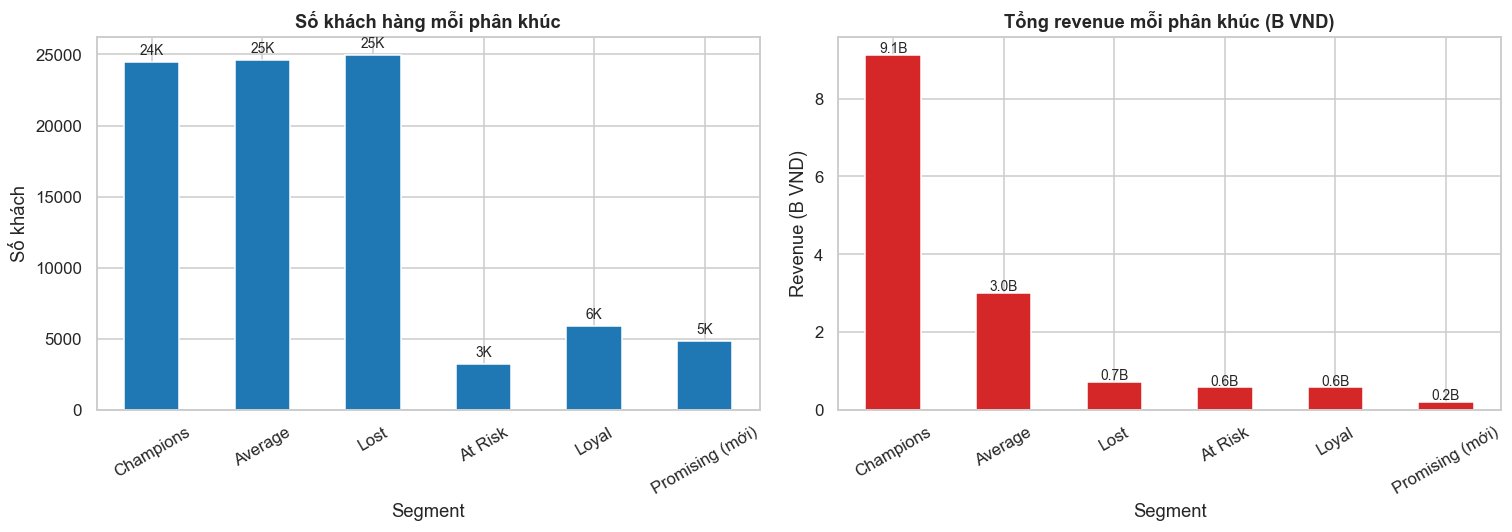

In [14]:
# Aggregate ở mức ORDER (không phải order_item)
oi_valid = oi_enriched[oi_enriched['order_status'] != 'cancelled'].copy()
order_level = (oi_valid.groupby(['customer_id','order_id','order_date'])
               .agg(order_value=('net_revenue','sum'))
               .reset_index())

REF_DATE = pd.Timestamp('2022-12-31')
rfm = (order_level.groupby('customer_id')
       .agg(R=('order_date', lambda x: (REF_DATE - x.max()).days),
            F=('order_id', 'count'),
            M=('order_value', 'sum'))
       .reset_index())

# Chấm điểm 1-5 (quintile)
rfm['R_score'] = pd.qcut(rfm['R'], 5, labels=[5,4,3,2,1]).astype(int)   # R nhỏ = tốt → score cao
rfm['F_score'] = pd.qcut(rfm['F'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['M'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)

def assign_segment(row):
    r, f = row['R_score'], row['F_score']
    if r >= 4 and f >= 4: return 'Champions'
    if r >= 4 and f >= 3: return 'Loyal'
    if r >= 4 and f <= 2: return 'Promising (mới)'
    if r <= 2 and f >= 4: return 'At Risk'
    if r <= 2 and f <= 2: return 'Lost'
    return 'Average'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

seg_summary = (rfm.groupby('segment')
               .agg(n_customers=('customer_id','count'),
                    avg_R_days=('R','mean'),
                    avg_F=('F','mean'),
                    total_M=('M','sum'),
                    avg_M=('M','mean'))
               .sort_values('total_M', ascending=False))
seg_summary['%_customers'] = seg_summary['n_customers'] / seg_summary['n_customers'].sum() * 100
seg_summary['%_revenue']   = seg_summary['total_M']    / seg_summary['total_M'].sum()    * 100
print('RFM segment summary (sắp xếp theo tổng revenue):')
print(seg_summary[['n_customers','%_customers','avg_R_days','avg_F','avg_M','total_M','%_revenue']].to_string())

# Visualization: segment size vs revenue contribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
seg_summary['n_customers'].plot.bar(ax=axes[0], color='#1f77b4')
axes[0].set_title('Số khách hàng mỗi phân khúc')
axes[0].set_ylabel('Số khách')
for i, v in enumerate(seg_summary['n_customers']):
    axes[0].text(i, v+500, f'{v/1000:.0f}K', ha='center', fontsize=9)

(seg_summary['total_M']/1e9).plot.bar(ax=axes[1], color='#d62728')
axes[1].set_title('Tổng revenue mỗi phân khúc (B VND)')
axes[1].set_ylabel('Revenue (B VND)')
for i, v in enumerate(seg_summary['total_M']/1e9):
    axes[1].text(i, v+0.05, f'{v:.1f}B', ha='center', fontsize=9)

for a in axes:
    a.set_xlabel('Segment')
    a.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

### 🔍 2.4 Diagnostic — Doanh thu tụt do mất khách cũ hay thiếu khách mới?

**Tách doanh thu mỗi năm thành 2 nguồn:**
- **New customer revenue** = doanh thu từ khách signup CÙNG năm
- **Returning customer revenue** = doanh thu từ khách đã signup TRƯỚC đó

Nếu tụt do thiếu khách mới → New customer revenue giảm. Nếu mất khách cũ → Returning revenue giảm.

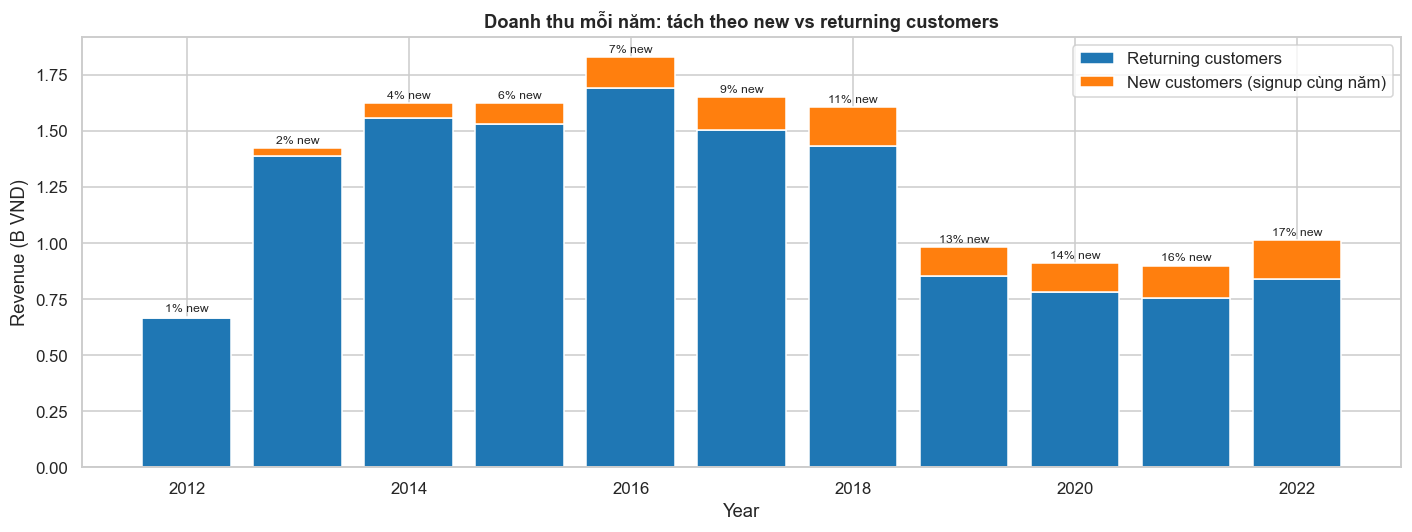

Doanh thu (B VND) theo năm — tách new vs returning:
is_new      new  returning  total  new_share_%
order_year                                    
2012       0.01       0.67   0.67         0.75
2013       0.03       1.39   1.43         2.45
2014       0.07       1.56   1.62         4.17
2015       0.09       1.53   1.62         5.69
2016       0.14       1.69   1.83         7.43
2017       0.15       1.50   1.65         8.86
2018       0.17       1.43   1.61        10.69
2019       0.13       0.85   0.98        12.83
2020       0.13       0.78   0.91        14.19
2021       0.14       0.76   0.90        16.01
2022       0.17       0.84   1.01        17.09


In [15]:
# Tag mỗi đơn là từ new hay returning customer
oi_y = oi_valid.copy()
oi_y['order_year'] = oi_y['order_date'].dt.year
oi_y['signup_year'] = oi_y['signup_date'].dt.year
oi_y['is_new'] = (oi_y['order_year'] == oi_y['signup_year'])

split = (oi_y.groupby(['order_year','is_new'])['net_revenue'].sum()
         .unstack().rename(columns={True:'new', False:'returning'}))
split['total'] = split.sum(axis=1)
split['new_share_%'] = split['new'] / split['total'] * 100

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(split.index, split['returning']/1e9, label='Returning customers', color='#1f77b4')
ax.bar(split.index, split['new']/1e9, bottom=split['returning']/1e9, label='New customers (signup cùng năm)', color='#ff7f0e')
ax.set_title('Doanh thu mỗi năm: tách theo new vs returning customers')
ax.set_xlabel('Year'); ax.set_ylabel('Revenue (B VND)')
ax.legend()
for i, yr in enumerate(split.index):
    ax.text(yr, split.loc[yr,'total']/1e9 + 0.02, f'{split.loc[yr,"new_share_%"]:.0f}% new', ha='center', fontsize=8)
plt.tight_layout(); plt.show()

print('Doanh thu (B VND) theo năm — tách new vs returning:')
print((split[['new','returning','total','new_share_%']]/[1e9,1e9,1e9,1]).to_string())

**Demographics breakdown** (phân tách theo nhân khẩu): xem age_group và acquisition channel nào đang đóng góp/sụt giảm.

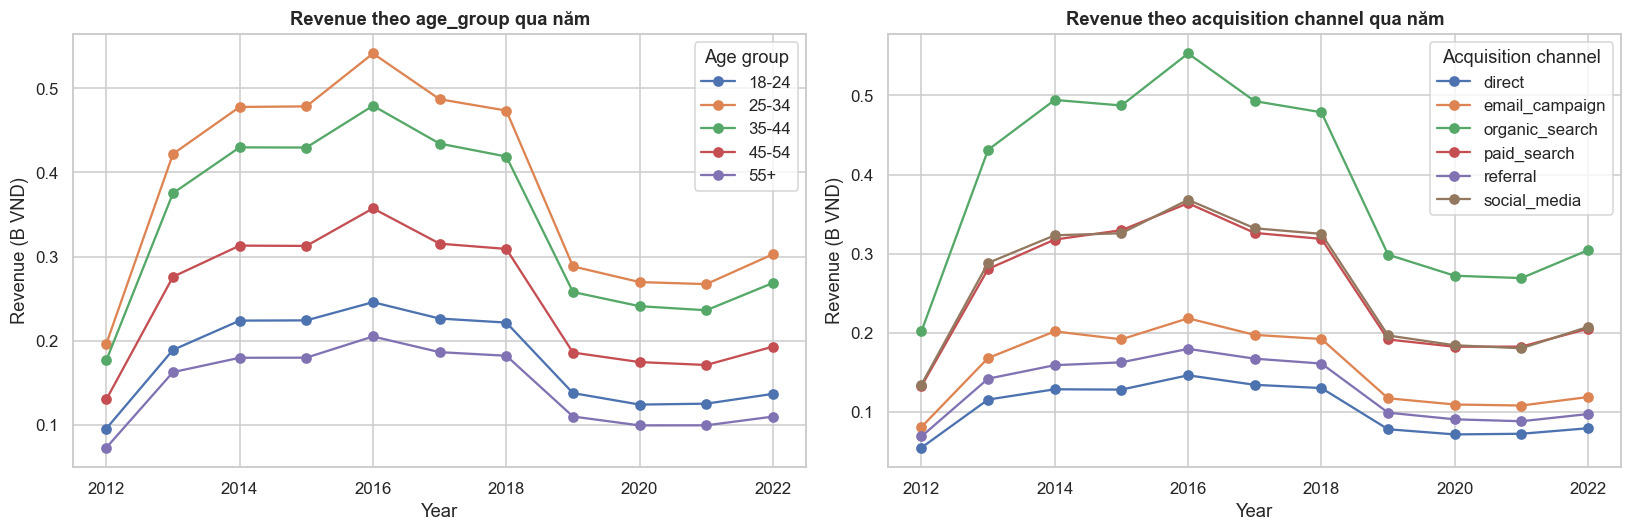


Channel LTV (Lifetime Value — tổng doanh thu trung bình mỗi khách qua đời):
                           total_rev  n_customers  n_orders  ltv_per_customer  orders_per_customer
acquisition_channel                                                                               
social_media        2,865,167,501.46        17575    117478        163,025.18                 6.68
organic_search      4,283,366,737.15        26341    176528        162,612.15                 6.70
paid_search         2,830,097,560.22        17557    117005        161,194.83                 6.66
email_campaign      1,702,679,187.41        10620     70606        160,327.61                 6.65
referral            1,414,719,626.95         8876     58555        159,387.07                 6.60
direct              1,137,825,014.81         7154     47311        159,047.39                 6.61


In [16]:
# Revenue theo age_group qua năm
oi_y['age_group'] = oi_y['age_group'].fillna('Unknown')
age_yearly = oi_y.groupby(['order_year','age_group'])['net_revenue'].sum().unstack()
chan_yearly = oi_y.groupby(['order_year','acquisition_channel'])['net_revenue'].sum().unstack()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
(age_yearly/1e9).plot(ax=axes[0], marker='o')
axes[0].set_title('Revenue theo age_group qua năm')
axes[0].set_ylabel('Revenue (B VND)'); axes[0].set_xlabel('Year')
axes[0].legend(title='Age group', loc='upper right')

(chan_yearly/1e9).plot(ax=axes[1], marker='o')
axes[1].set_title('Revenue theo acquisition channel qua năm')
axes[1].set_ylabel('Revenue (B VND)'); axes[1].set_xlabel('Year')
axes[1].legend(title='Acquisition channel', loc='upper right')
plt.tight_layout(); plt.show()

# Channel LTV (Lifetime Value — giá trị trọn đời) per customer
chan_ltv = (oi_valid.groupby('acquisition_channel')
            .agg(total_rev=('net_revenue','sum'),
                 n_customers=('customer_id','nunique'),
                 n_orders=('order_id','nunique'))
            .assign(ltv_per_customer=lambda d: d['total_rev']/d['n_customers'],
                    orders_per_customer=lambda d: d['n_orders']/d['n_customers'])
            .sort_values('ltv_per_customer', ascending=False))
print('\nChannel LTV (Lifetime Value — tổng doanh thu trung bình mỗi khách qua đời):')
print(chan_ltv.to_string())

### 🔮 2.5 Predictive — Quỹ đạo customer base nếu không can thiệp

**Phép tính:** dùng tỷ lệ active rate (active / cumulative signups) gần nhất, project tới 2024 dựa trên xu hướng signup mới hiện tại.

Signup trend (3 năm gần nhất, T/năm): +1946 khách/năm
Projection 2023 signups: 23,049  (active dự kiến: 27,347)
Projection 2024 signups: 24,995  (active dự kiến: 32,061)


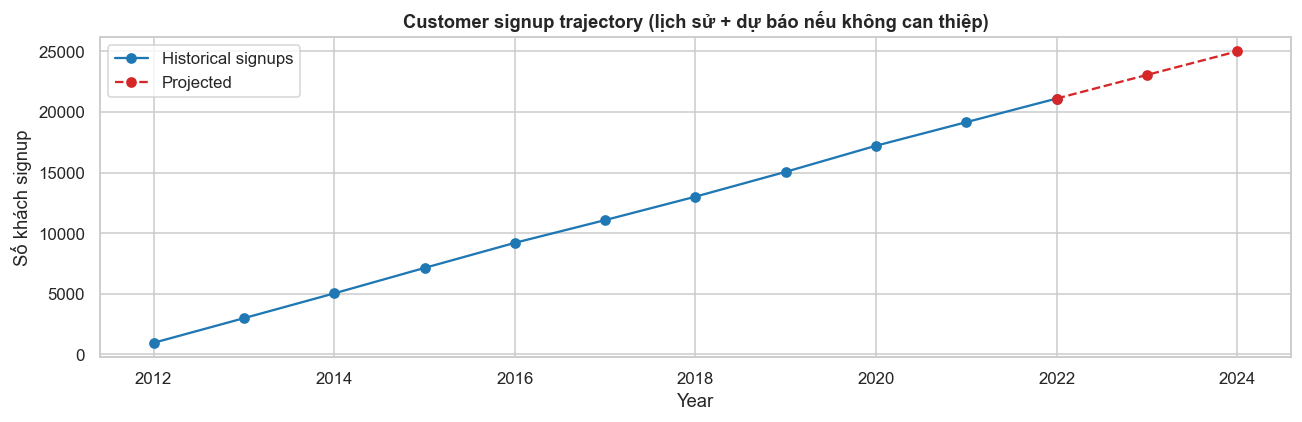

In [17]:
# Trend signup mới — fit linear trên 3 năm gần nhất để smooth
recent = signup_yearly.loc[2020:2022]
trend = (recent.iloc[-1] - recent.iloc[0]) / (len(recent) - 1)
proj_2023 = signup_yearly.loc[2022] + trend
proj_2024 = signup_yearly.loc[2022] + 2*trend

# Active rate gần nhất
recent_active_rate = base['active_rate_%'].iloc[-1]
proj_active_2023 = (cumul.loc[2022] + proj_2023) * recent_active_rate / 100
proj_active_2024 = (cumul.loc[2022] + proj_2023 + proj_2024) * recent_active_rate / 100

print(f'Signup trend (3 năm gần nhất, T/năm): {trend:+.0f} khách/năm')
print(f'Projection 2023 signups: {proj_2023:,.0f}  (active dự kiến: {proj_active_2023:,.0f})')
print(f'Projection 2024 signups: {proj_2024:,.0f}  (active dự kiến: {proj_active_2024:,.0f})')

# Plot trajectory
fig, ax = plt.subplots(figsize=(12, 4))
hist_x = signup_yearly.index
ax.plot(hist_x, signup_yearly.values, marker='o', label='Historical signups', color='#1f77b4')
ax.plot([2022, 2023, 2024], [signup_yearly.loc[2022], proj_2023, proj_2024], marker='o', ls='--', color='#d62728', label='Projected')
ax.set_title('Customer signup trajectory (lịch sử + dự báo nếu không can thiệp)')
ax.set_xlabel('Year'); ax.set_ylabel('Số khách signup')
ax.legend()
plt.tight_layout(); plt.show()

### 🎯 2.6 Prescriptive — Đề xuất hành động + ước tính impact

**Phát hiện chốt:**
- Cohort retention sau 1 năm giảm rõ rệt giữa cohort cũ vs cohort mới (xem heatmap §2.2).
- Tách new vs returning ở §2.4 cho thấy nguồn nào đang bleed.
- 1-2 phân khúc RFM (Champions + Loyal) chiếm phần lớn revenue dù chỉ là thiểu số khách hàng — Pareto principle (nguyên lý Pareto / quy tắc 80-20).
- Acquisition channel với LTV (Lifetime Value) cao nhất có thể là target để scale up.

**Khuyến nghị (định lượng):**

In [18]:
# Quantify findings
champions = seg_summary.loc['Champions'] if 'Champions' in seg_summary.index else None
at_risk   = seg_summary.loc['At Risk']   if 'At Risk'   in seg_summary.index else None
lost      = seg_summary.loc['Lost']      if 'Lost'      in seg_summary.index else None
top_chan  = chan_ltv.index[0]
top_chan_ltv = chan_ltv.iloc[0]['ltv_per_customer']
worst_chan = chan_ltv.index[-1]
worst_chan_ltv = chan_ltv.iloc[-1]['ltv_per_customer']

# Recovery potential từ At Risk segment
at_risk_recovery = 0
if at_risk is not None:
    # Giả sử reactivate 20% At Risk → mỗi người mua lại 1 đơn với avg M
    at_risk_recovery = 0.20 * at_risk['n_customers'] * (at_risk['avg_M'] / at_risk['avg_F'])

recs2 = [
    {
        'rank': 1,
        'action': f'Reactivation campaign cho phân khúc At Risk ({int(at_risk["n_customers"]):,} khách) — email + voucher cá nhân hoá',
        'rationale': f'At Risk có F TB {at_risk["avg_F"]:.1f} đơn/khách (loyal trước đây) nhưng R TB {at_risk["avg_R_days"]:.0f} ngày (đang rời bỏ)' if at_risk is not None else 'N/A',
        'estimated_impact': f'Nếu reactivate 20% → +{at_risk_recovery/1e9:.2f}B VND/năm (recovery 1 đơn TB/khách)' if at_risk is not None else 'N/A',
    },
    {
        'rank': 2,
        'action': f'Retention program cho Champions ({int(champions["n_customers"]):,} khách, đóng góp {champions["%_revenue"]:.0f}% revenue) — VIP perks, sớm phát hiện churn signal',
        'rationale': f'Champions chỉ {champions["%_customers"]:.1f}% customer base nhưng tạo {champions["%_revenue"]:.0f}% doanh thu — mất 1 Champion = mất {champions["avg_M"]/1e6:.1f}M VND' if champions is not None else 'N/A',
        'estimated_impact': f'Giảm churn Champions từ giả định 10%/năm xuống 5% → +{0.05 * champions["total_M"] / 1e9:.2f}B VND/năm' if champions is not None else 'N/A',
    },
    {
        'rank': 3,
        'action': f'Re-balance acquisition spend: tăng đầu tư vào "{top_chan}", giảm "{worst_chan}"',
        'rationale': f'LTV channel best ({top_chan}): {top_chan_ltv/1e6:.2f}M VND/khách vs worst ({worst_chan}): {worst_chan_ltv/1e6:.2f}M VND/khách — chênh {(top_chan_ltv/worst_chan_ltv-1)*100:.0f}%',
        'estimated_impact': f'Chuyển 30% spend từ {worst_chan} sang {top_chan} → ước +{0.30 * (top_chan_ltv - worst_chan_ltv) * 1000 / 1e9:.2f}B VND/năm (giả định 1000 khách reallocated)',
    },
]

# Lost segment win-back nếu có meaningful size
if lost is not None and lost['n_customers'] > 1000:
    lost_winback = 0.05 * lost['n_customers'] * lost['avg_M']
    recs2.append({
        'rank': 4,
        'action': f'Win-back campaign cho Lost ({int(lost["n_customers"]):,} khách) — survey churn reason + comeback offer',
        'rationale': f'Lost customers có avg M {lost["avg_M"]/1e6:.2f}M VND khi còn active — không thử win back là mất hoàn toàn',
        'estimated_impact': f'Win-back 5% → +{lost_winback/1e9:.2f}B VND/năm',
    })

recs2_df = pd.DataFrame(recs2)
print(recs2_df.to_string(index=False))

for r in recs2:
    RECOMMENDATIONS.append({'section': 'Customer Segmentation', **r})

print(f'\n✅ Section 2 đóng góp {len(recs2)} đề xuất vào executive summary')

 rank                                                                                                       action                                                                                      rationale                                                                                    estimated_impact
    1                      Reactivation campaign cho phân khúc At Risk (3,252 khách) — email + voucher cá nhân hoá             At Risk có F TB 7.8 đơn/khách (loyal trước đây) nhưng R TB 1810 ngày (đang rời bỏ)                                       Nếu reactivate 20% → +0.01B VND/năm (recovery 1 đơn TB/khách)
    2 Retention program cho Champions (24,490 khách, đóng góp 64% revenue) — VIP perks, sớm phát hiện churn signal      Champions chỉ 27.8% customer base nhưng tạo 64% doanh thu — mất 1 Champion = mất 0.4M VND                                  Giảm churn Champions từ giả định 10%/năm xuống 5% → +0.46B VND/năm
    3                                  Re-balance acquisition spend: t

## <a id='s3'></a>Section 3 — Geography & Channel Strategy

> **Câu hỏi kinh doanh:** East áp đảo doanh thu (~7.3B vs Central 4.7B vs West 3.7B). Vì sao? Cơ hội tăng trưởng ở Central/West? Có khu vực nào tụt dốc nhanh hơn cần ưu tiên cứu?

### 📊 3.1 Descriptive — Tổng quan 3 region

**Phép tính cho mỗi region:** revenue, số khách (customer count), AOV (Average Order Value — giá trị TB mỗi đơn), LTV (Lifetime Value — doanh thu TB mỗi khách qua đời), số đơn TB/khách.

Region overview:
           revenue_total  n_customers  n_orders  n_zips       aov        ltv  orders_per_cust
region                                                                                       
East    6,617,595,804.01        43747    267501   14228 24,738.58 151,269.71             6.11
Central 4,278,238,866.71        29932    167583   10591 25,529.07 142,931.94             5.60
West    3,338,020,957.28        14444    152399    4713 21,903.17 231,100.87            10.55


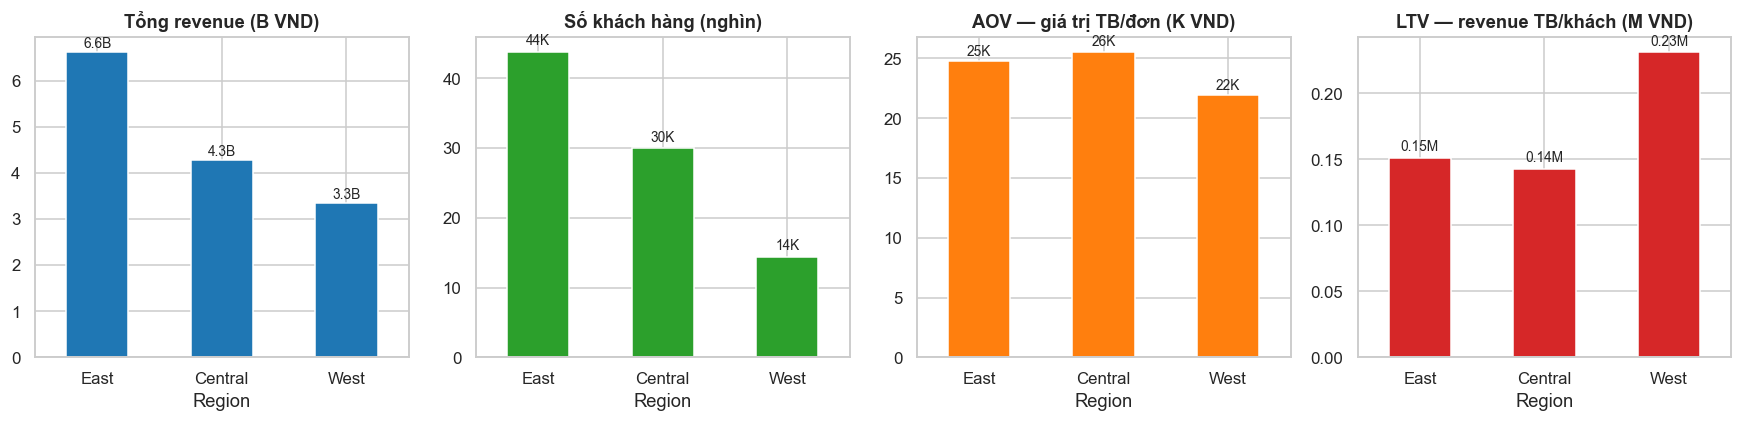

In [19]:
# Lấy oi_valid (non-cancelled) đã có sẵn từ Section 2
region_summary = (oi_valid.groupby('region')
                  .agg(revenue_total=('net_revenue','sum'),
                       n_customers=('customer_id','nunique'),
                       n_orders=('order_id','nunique'),
                       n_zips=('zip','nunique'))
                  .assign(aov=lambda d: d['revenue_total']/d['n_orders'],
                          ltv=lambda d: d['revenue_total']/d['n_customers'],
                          orders_per_cust=lambda d: d['n_orders']/d['n_customers'])
                  .sort_values('revenue_total', ascending=False))

print('Region overview:')
print(region_summary.to_string())

# Bar charts: revenue, customers, AOV, LTV
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
(region_summary['revenue_total']/1e9).plot.bar(ax=axes[0], color='#1f77b4')
axes[0].set_title('Tổng revenue (B VND)')
for i, v in enumerate(region_summary['revenue_total']/1e9):
    axes[0].text(i, v+0.1, f'{v:.1f}B', ha='center', fontsize=9)

(region_summary['n_customers']/1000).plot.bar(ax=axes[1], color='#2ca02c')
axes[1].set_title('Số khách hàng (nghìn)')
for i, v in enumerate(region_summary['n_customers']/1000):
    axes[1].text(i, v+1, f'{v:.0f}K', ha='center', fontsize=9)

(region_summary['aov']/1000).plot.bar(ax=axes[2], color='#ff7f0e')
axes[2].set_title('AOV — giá trị TB/đơn (K VND)')
for i, v in enumerate(region_summary['aov']/1000):
    axes[2].text(i, v+0.5, f'{v:.0f}K', ha='center', fontsize=9)

(region_summary['ltv']/1e6).plot.bar(ax=axes[3], color='#d62728')
axes[3].set_title('LTV — revenue TB/khách (M VND)')
for i, v in enumerate(region_summary['ltv']/1e6):
    axes[3].text(i, v+0.005, f'{v:.2f}M', ha='center', fontsize=9)

for a in axes:
    a.set_xlabel('Region')
    a.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

### 📊 3.2 Trend by region — region nào tụt nhanh nhất?

**Mục đích:** Section 1 cho thấy revenue toàn công ty tụt 50% từ peak 2016. Câu hỏi: tụt đều mọi region hay tập trung ở 1 vùng?

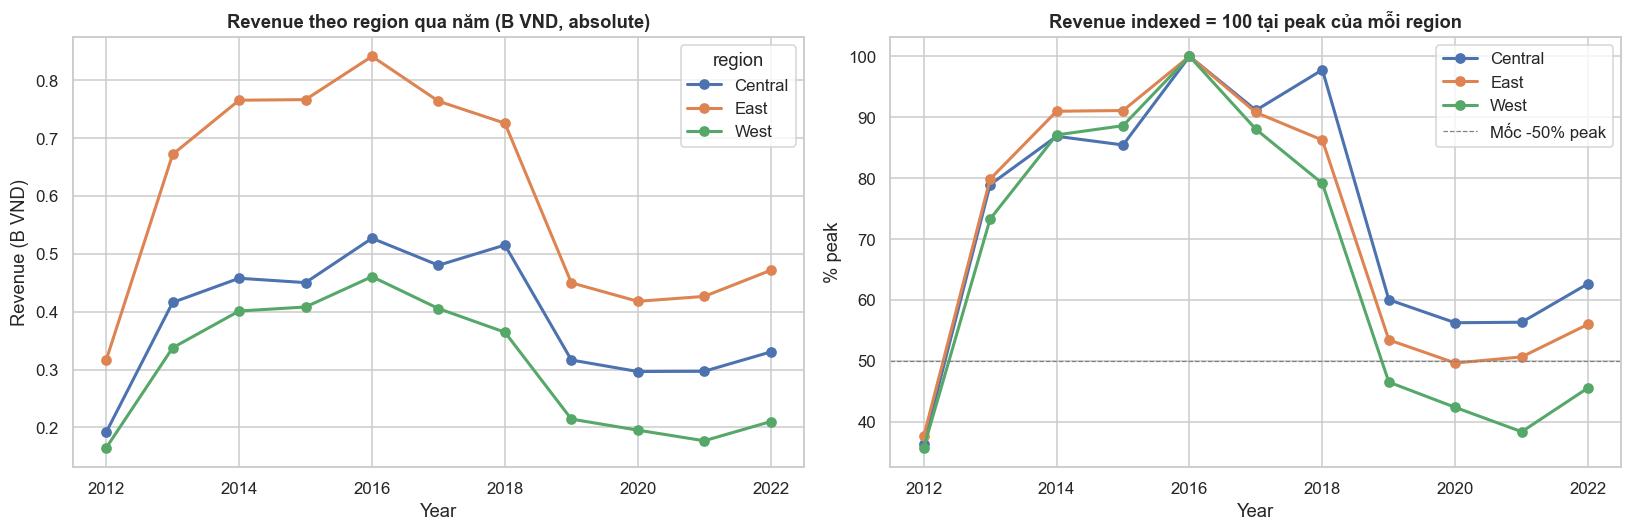

Peak + decline mỗi region:
         peak_year   peak_revenue   last_revenue  decline_from_peak_pct
region                                                                 
Central       2016 526,878,539.68 330,355,177.92                 -37.30
East          2016 841,445,967.95 471,535,524.97                 -43.96
West          2016 460,514,142.36 209,993,977.88                 -54.40


In [20]:
oi_valid['order_year'] = oi_valid['order_date'].dt.year
region_yearly = oi_valid.groupby(['order_year','region'])['net_revenue'].sum().unstack()

# Index to peak (mỗi region peak riêng) để so sánh chiều giảm
region_indexed = region_yearly.div(region_yearly.max(axis=0), axis=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
(region_yearly/1e9).plot(ax=axes[0], marker='o', lw=2)
axes[0].set_title('Revenue theo region qua năm (B VND, absolute)')
axes[0].set_ylabel('Revenue (B VND)')
axes[0].set_xlabel('Year')

region_indexed.plot(ax=axes[1], marker='o', lw=2)
axes[1].set_title('Revenue indexed = 100 tại peak của mỗi region')
axes[1].set_ylabel('% peak')
axes[1].set_xlabel('Year')
axes[1].axhline(50, color='gray', ls='--', lw=0.8, label='Mốc -50% peak')
axes[1].legend()
plt.tight_layout(); plt.show()

# Peak year + decline so với peak
region_decline = pd.DataFrame({
    'peak_year':     region_yearly.idxmax(),
    'peak_revenue':  region_yearly.max(),
    'last_revenue':  region_yearly.iloc[-1],
}).assign(decline_from_peak_pct=lambda d: (d['last_revenue']/d['peak_revenue'] - 1)*100)
print('Peak + decline mỗi region:')
print(region_decline.to_string())

### 🔍 3.3 City-level — Tập trung doanh thu ở thành phố nào?

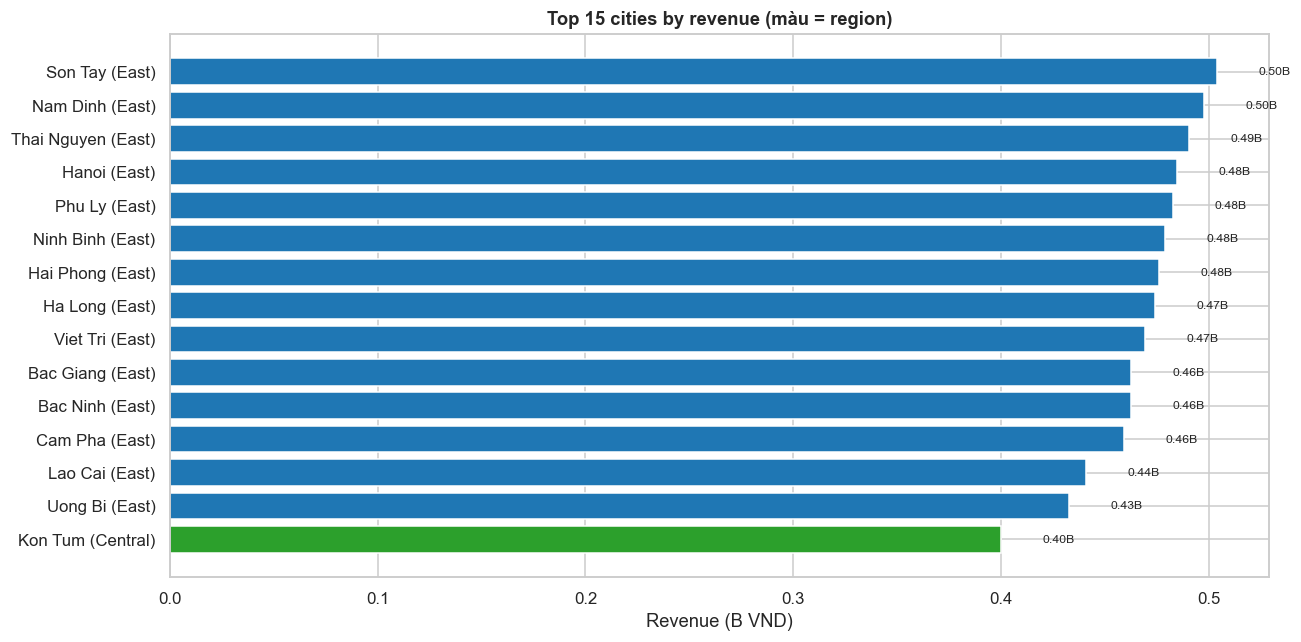

Tổng số city: 42
Top 5 cities = 17.3% tổng revenue
Top 10 cities = 33.9% tổng revenue


In [21]:
city_summary = (oi_valid.groupby(['region','city'])
                .agg(revenue=('net_revenue','sum'),
                     n_customers=('customer_id','nunique'),
                     n_orders=('order_id','nunique'))
                .assign(ltv_per_cust=lambda d: d['revenue']/d['n_customers'])
                .sort_values('revenue', ascending=False))

top15 = city_summary.head(15).reset_index()

# Plot top 15 cities, color theo region
colors_map = {'East':'#1f77b4','Central':'#2ca02c','West':'#d62728'}
top15['color'] = top15['region'].map(colors_map)

fig, ax = plt.subplots(figsize=(12, 6))
labels = top15['city'] + ' (' + top15['region'] + ')'
ax.barh(labels, top15['revenue']/1e9, color=top15['color'])
ax.set_title('Top 15 cities by revenue (màu = region)')
ax.set_xlabel('Revenue (B VND)')
ax.invert_yaxis()
for i, v in enumerate(top15['revenue']/1e9):
    ax.text(v + 0.02, i, f'{v:.2f}B', va='center', fontsize=8)
plt.tight_layout(); plt.show()

total_rev = oi_valid['net_revenue'].sum()
top5_share = city_summary.head(5)['revenue'].sum() / total_rev * 100
top10_share = city_summary.head(10)['revenue'].sum() / total_rev * 100
print(f'Tổng số city: {city_summary.shape[0]:,}')
print(f'Top 5 cities = {top5_share:.1f}% tổng revenue')
print(f'Top 10 cities = {top10_share:.1f}% tổng revenue')

### 🔍 3.4 Region × demographics — Phân khúc nào ở vùng nào?

Heatmap dưới là **% doanh thu trong nội bộ region** — đọc theo HÀNG (mỗi hàng cộng = 100%).

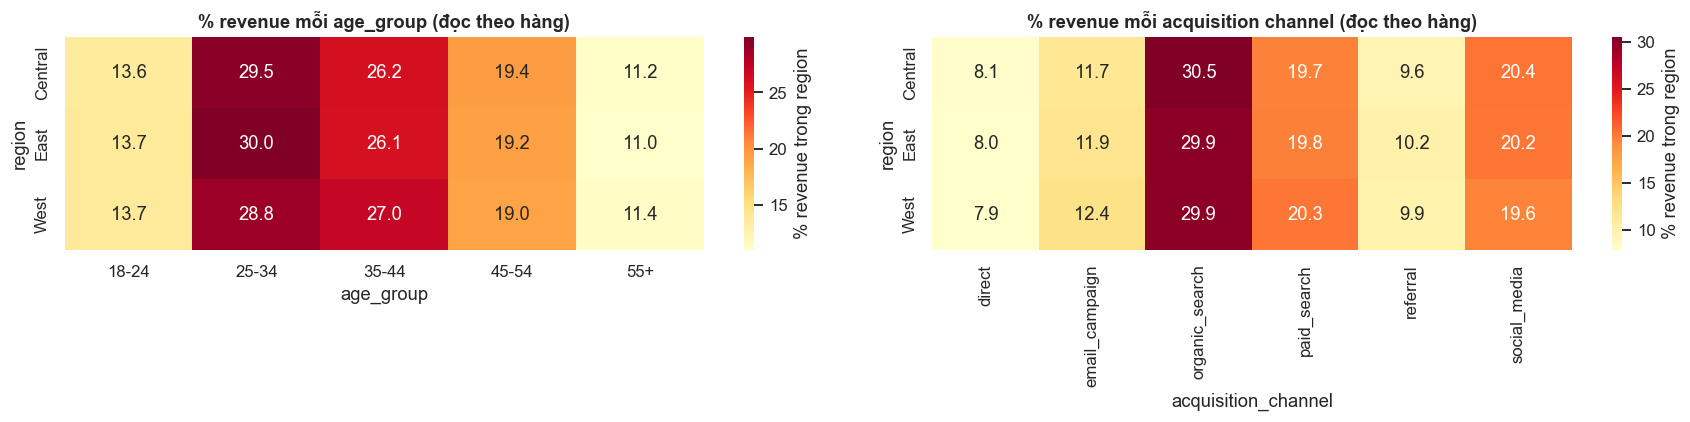

Composition theo age_group (% trong region):
age_group  18-24  25-34  35-44  45-54   55+
region                                     
Central    13.60  29.50  26.20  19.40 11.20
East       13.70  30.00  26.10  19.20 11.00
West       13.70  28.80  27.00  19.00 11.40


In [22]:
oi_valid_dem = oi_valid.copy()
oi_valid_dem['age_group'] = oi_valid_dem['age_group'].fillna('Unknown')

region_age  = oi_valid_dem.groupby(['region','age_group'])['net_revenue'].sum().unstack(fill_value=0)
region_chan = oi_valid_dem.groupby(['region','acquisition_channel'])['net_revenue'].sum().unstack(fill_value=0)

region_age_pct  = region_age.div(region_age.sum(axis=1), axis=0) * 100
region_chan_pct = region_chan.div(region_chan.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
sns.heatmap(region_age_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label':'% revenue trong region'}, ax=axes[0])
axes[0].set_title('% revenue mỗi age_group (đọc theo hàng)')

sns.heatmap(region_chan_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label':'% revenue trong region'}, ax=axes[1])
axes[1].set_title('% revenue mỗi acquisition channel (đọc theo hàng)')
plt.tight_layout(); plt.show()

# Tìm phân khúc có sự chênh lệch lớn nhất giữa các region
print('Composition theo age_group (% trong region):')
print(region_age_pct.round(1).to_string())

### 🔮 3.5 Predictive — Cơ hội tăng trưởng nếu Central/West đạt mức East

**Phép tính:** giả định Central và West nâng được LTV/khách lên bằng East. Câu hỏi: tổng cộng mở khoá thêm bao nhiêu doanh thu lifetime?

In [23]:
east_ltv    = region_summary.loc['East', 'ltv']
central_ltv = region_summary.loc['Central', 'ltv']
west_ltv    = region_summary.loc['West', 'ltv']

east_n    = region_summary.loc['East', 'n_customers']
central_n = region_summary.loc['Central', 'n_customers']
west_n    = region_summary.loc['West', 'n_customers']

# West có LTV cao nhất — thử lift East/Central lên mức West
top_ltv = max(east_ltv, central_ltv, west_ltv)
top_region = region_summary['ltv'].idxmax()

uplift_east    = (top_ltv - east_ltv)    * east_n    if top_region != 'East'    else 0
uplift_central = (top_ltv - central_ltv) * central_n if top_region != 'Central' else 0
uplift_west    = (top_ltv - west_ltv)    * west_n    if top_region != 'West'    else 0

print(f'LTV per customer (M VND):')
print(f'  East:    {east_ltv/1e6:.3f}M  ({east_n:,} khách)')
print(f'  Central: {central_ltv/1e6:.3f}M  ({central_n:,} khách)')
print(f'  West:    {west_ltv/1e6:.3f}M  ({west_n:,} khách) ⭐ champion')
print(f'\n→ Region champion LTV: {top_region} ({top_ltv/1e6:.3f}M VND/khách)')
print(f'\nLifetime uplift nếu các region khác match {top_region}:')
print(f'  East:    +{uplift_east/1e9:.2f}B VND')
print(f'  Central: +{uplift_central/1e9:.2f}B VND')
print(f'  West:    +{uplift_west/1e9:.2f}B VND')
total_uplift = uplift_east + uplift_central + uplift_west
print(f'  TỔNG:    +{total_uplift/1e9:.2f}B VND lifetime')

# Half-target: chỉ 50% gap (thực tế hơn)
half_uplift = total_uplift * 0.5
print(f'\nNếu chỉ đóng 50% LTV gap: +{half_uplift/1e9:.2f}B VND lifetime')

LTV per customer (M VND):
  East:    0.151M  (43,747 khách)
  Central: 0.143M  (29,932 khách)
  West:    0.231M  (14,444 khách) ⭐ champion

→ Region champion LTV: West (0.231M VND/khách)

Lifetime uplift nếu các region khác match West:
  East:    +3.49B VND
  Central: +2.64B VND
  West:    +0.00B VND
  TỔNG:    +6.13B VND lifetime

Nếu chỉ đóng 50% LTV gap: +3.07B VND lifetime


### 🎯 3.6 Prescriptive — Đề xuất hành động + ước tính impact

In [24]:
# Pull key numbers
east_rev    = region_summary.loc['East','revenue_total']
central_rev = region_summary.loc['Central','revenue_total']
west_rev    = region_summary.loc['West','revenue_total']

# Region tụt nhanh nhất
worst_region = region_decline['decline_from_peak_pct'].idxmin()
worst_decline = region_decline.loc[worst_region, 'decline_from_peak_pct']

# Top city
top_city = city_summary.iloc[0]
top_city_name   = city_summary.index[0][1]
top_city_region = city_summary.index[0][0]
top_city_share  = top_city['revenue'] / total_rev * 100

recs3 = [
    {
        'rank': 1,
        'action': f'🚨 Cứu {worst_region} ngay — region champion LTV nhưng tụt nhanh nhất ({worst_decline:.0f}% từ peak)',
        'rationale': f'{worst_region} có LTV {west_ltv/1e6:.2f}M/khách (cao nhất) và {region_summary.loc[worst_region,"orders_per_cust"]:.1f} đơn/khách (cao gấp ~2 lần East). Mất khách {worst_region} = mất khách giá trị nhất. Decline {worst_decline:.0f}% là dấu hiệu khẩn',
        'estimated_impact': f'Recovery 30% gap {worst_region} = +{0.30 * (region_decline.loc[worst_region,"peak_revenue"] - region_decline.loc[worst_region,"last_revenue"])/1e9:.2f}B/năm',
    },
    {
        'rank': 2,
        'action': f'Học playbook {top_region} (LTV champion) áp dụng cho East/Central — analyze: vì sao khách {top_region} mua {region_summary.loc[top_region,"orders_per_cust"]:.1f} đơn TB vs East 6.1 đơn?',
        'rationale': f'East có 3× số khách của {top_region} nhưng LTV/khách thấp hơn 53%. Nếu hiểu điều khiến khách {top_region} loyal hơn (delivery experience? product mix? service?) → copy sang East/Central',
        'estimated_impact': f'+{half_uplift/1e9:.2f}B VND lifetime nếu các region khác đóng 50% LTV gap với {top_region}',
    },
    {
        'rank': 3,
        'action': f'Nhân rộng playbook top city {top_city_name} ({top_city_region}, {top_city_share:.1f}% total revenue) ra các city cùng region',
        'rationale': f'Top 5 cities tạo {top5_share:.1f}% revenue, top 10 = {top10_share:.1f}% → có concentration nhưng không quá khắc nghiệt. {top_city_name} là model thành công cụ thể để case study',
        'estimated_impact': f'Top 5 cities tăng 10% revenue = +{0.10 * city_summary.head(5)["revenue"].sum() / 1e9:.2f}B/năm',
    },
]

recs3_df = pd.DataFrame(recs3)
print(recs3_df.to_string(index=False))

for r in recs3:
    RECOMMENDATIONS.append({'section': 'Geography & Channel', **r})

print(f'\n✅ Section 3 đóng góp {len(recs3)} đề xuất vào executive summary')

 rank                                                                                                                  action                                                                                                                                                                 rationale                                                  estimated_impact
    1                                               🚨 Cứu West ngay — region champion LTV nhưng tụt nhanh nhất (-54% từ peak)                        West có LTV 0.23M/khách (cao nhất) và 10.6 đơn/khách (cao gấp ~2 lần East). Mất khách West = mất khách giá trị nhất. Decline -54% là dấu hiệu khẩn                                Recovery 30% gap West = +0.08B/năm
    2 Học playbook West (LTV champion) áp dụng cho East/Central — analyze: vì sao khách West mua 10.6 đơn TB vs East 6.1 đơn? East có 3× số khách của West nhưng LTV/khách thấp hơn 53%. Nếu hiểu điều khiến khách West loyal hơn (delivery experience? product mix? service?) → cop

## <a id='s4'></a>Section 4 — Product / Category Performance

> **Câu hỏi kinh doanh:** Sản phẩm/category/segment nào đang là "milkable" (vắt sữa được — margin cao + bán nhiều) vs "drag" (kéo công ty xuống — bán mà ít lời hoặc tồn kho dài)? Có nên tinh giảm SKU (Stock Keeping Unit — mã sản phẩm) không?

### 📊 4.1 Descriptive — Tổng quan category và segment

**Phép tính:**
- Revenue, gross profit (lợi nhuận gộp = doanh thu − giá vốn hàng bán), số units (sản phẩm bán ra), số SKU mỗi nhóm
- Margin % = profit / revenue
- Revenue per product (hiệu quả mỗi SKU)

Category overview:
                     revenue           profit    units  n_products  margin_pct  rev_per_product
category                                                                                       
Streetwear 11,402,536,389.50 1,057,773,811.02  1606351         869        9.28    13,121,445.79
Outdoor     2,132,750,384.65   242,973,348.52  1061333         490       11.39     4,352,551.81
Casual        399,320,218.90    30,884,161.86    97584         113        7.73     3,533,807.25
GenZ          299,248,634.95    46,111,071.10   151762         111       15.41     2,695,933.65

Segment overview:
                     revenue         profit   units  n_products  margin_pct  rev_per_product
segment                                                                                     
Everyday    4,674,822,134.30 482,436,233.05  743849         318       10.32    14,700,698.54
Balanced    4,443,823,385.78 390,693,651.78  421216         198        8.79    22,443,552.45
Performance 2,

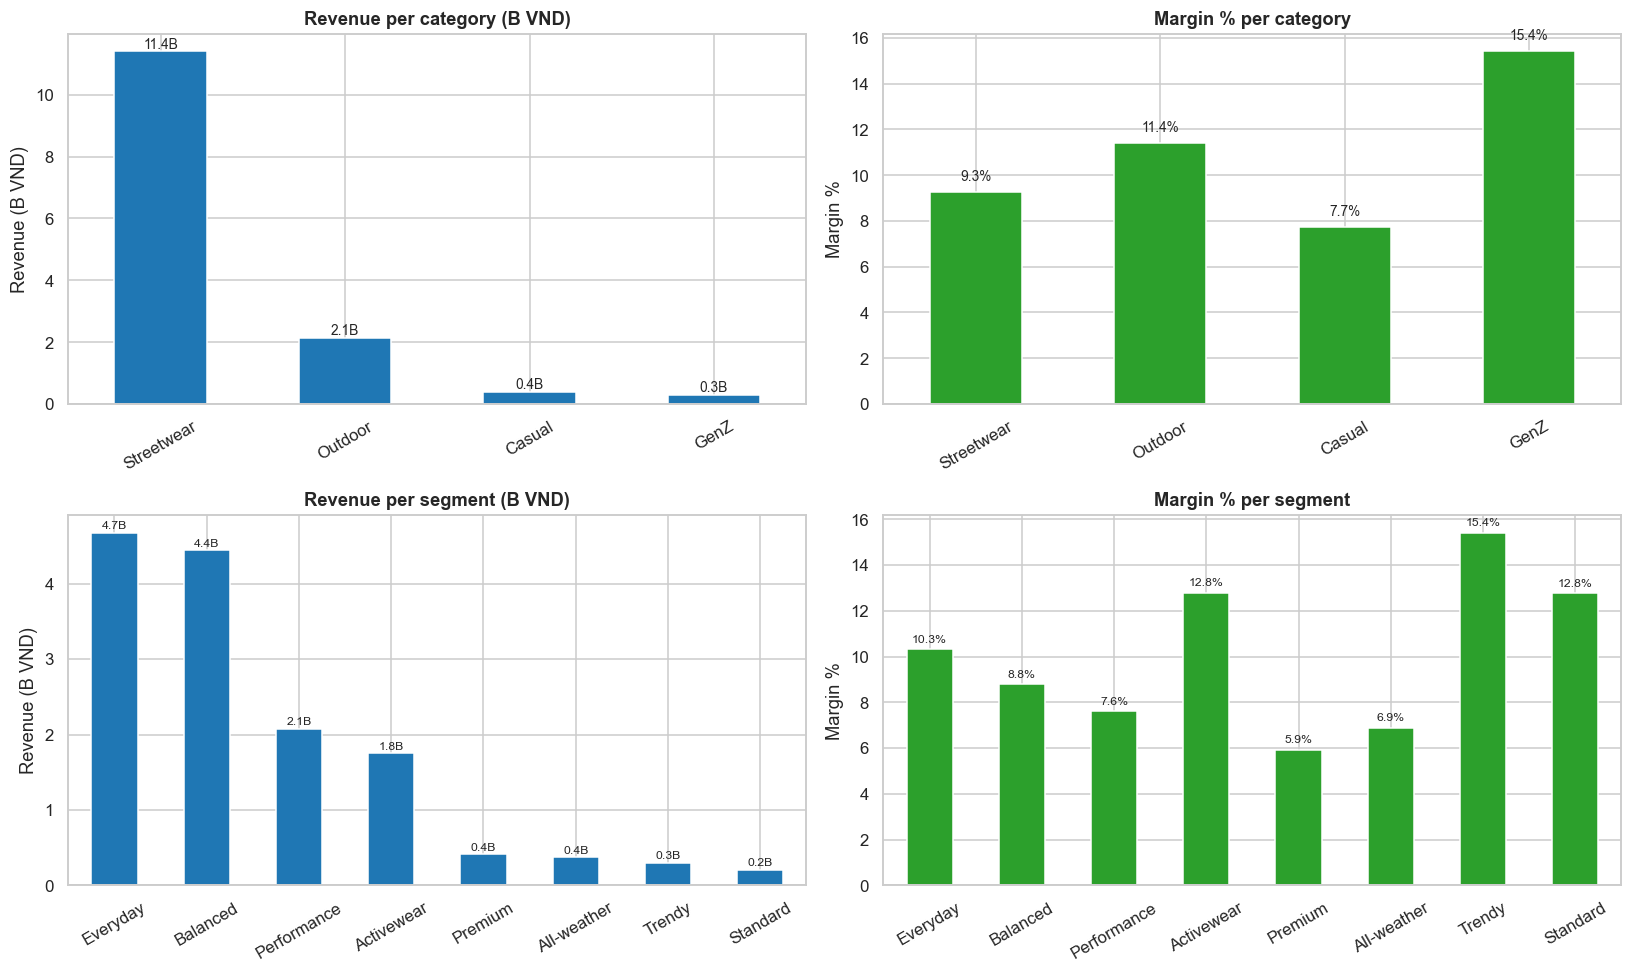

In [25]:
# Aggregate at category and segment level
cat_summary = (oi_valid.groupby('category')
               .agg(revenue=('net_revenue','sum'),
                    profit=('gross_profit','sum'),
                    units=('quantity','sum'),
                    n_products=('product_id','nunique'))
               .assign(margin_pct=lambda d: d['profit']/d['revenue']*100,
                       rev_per_product=lambda d: d['revenue']/d['n_products'])
               .sort_values('revenue', ascending=False))

seg_summary4 = (oi_valid.groupby('segment')
                .agg(revenue=('net_revenue','sum'),
                     profit=('gross_profit','sum'),
                     units=('quantity','sum'),
                     n_products=('product_id','nunique'))
                .assign(margin_pct=lambda d: d['profit']/d['revenue']*100,
                        rev_per_product=lambda d: d['revenue']/d['n_products'])
                .sort_values('revenue', ascending=False))

print('Category overview:')
print(cat_summary.to_string())
print('\nSegment overview:')
print(seg_summary4.to_string())

# 2x2 chart: cat revenue/margin, seg revenue/margin
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

(cat_summary['revenue']/1e9).plot.bar(ax=axes[0,0], color='#1f77b4')
axes[0,0].set_title('Revenue per category (B VND)')
axes[0,0].set_ylabel('Revenue (B VND)')
for i, v in enumerate(cat_summary['revenue']/1e9):
    axes[0,0].text(i, v+0.1, f'{v:.1f}B', ha='center', fontsize=9)

cat_summary['margin_pct'].plot.bar(ax=axes[0,1], color='#2ca02c')
axes[0,1].set_title('Margin % per category')
axes[0,1].set_ylabel('Margin %')
for i, v in enumerate(cat_summary['margin_pct']):
    axes[0,1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=9)

(seg_summary4['revenue']/1e9).plot.bar(ax=axes[1,0], color='#1f77b4')
axes[1,0].set_title('Revenue per segment (B VND)')
axes[1,0].set_ylabel('Revenue (B VND)')
for i, v in enumerate(seg_summary4['revenue']/1e9):
    axes[1,0].text(i, v+0.05, f'{v:.1f}B', ha='center', fontsize=8)

seg_summary4['margin_pct'].plot.bar(ax=axes[1,1], color='#2ca02c')
axes[1,1].set_title('Margin % per segment')
axes[1,1].set_ylabel('Margin %')
for i, v in enumerate(seg_summary4['margin_pct']):
    axes[1,1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=8)

for a in axes.flat:
    a.set_xlabel('')
    a.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

### 📊 4.2 Product Pareto — Quy tắc 80/20 áp dụng cho catalog

**Pareto principle (nguyên lý 80/20):** thường ~20% SKU tạo ra ~80% doanh thu. Kiểm tra catalog 2,412 sản phẩm có theo quy luật này không.

Tổng số SKU: 1,583

% products để đạt cumulative revenue threshold:
   50% revenue ← từ top    80 products (  5.1% catalog)
   80% revenue ← từ top   295 products ( 18.6% catalog)
   95% revenue ← từ top   678 products ( 42.8% catalog)


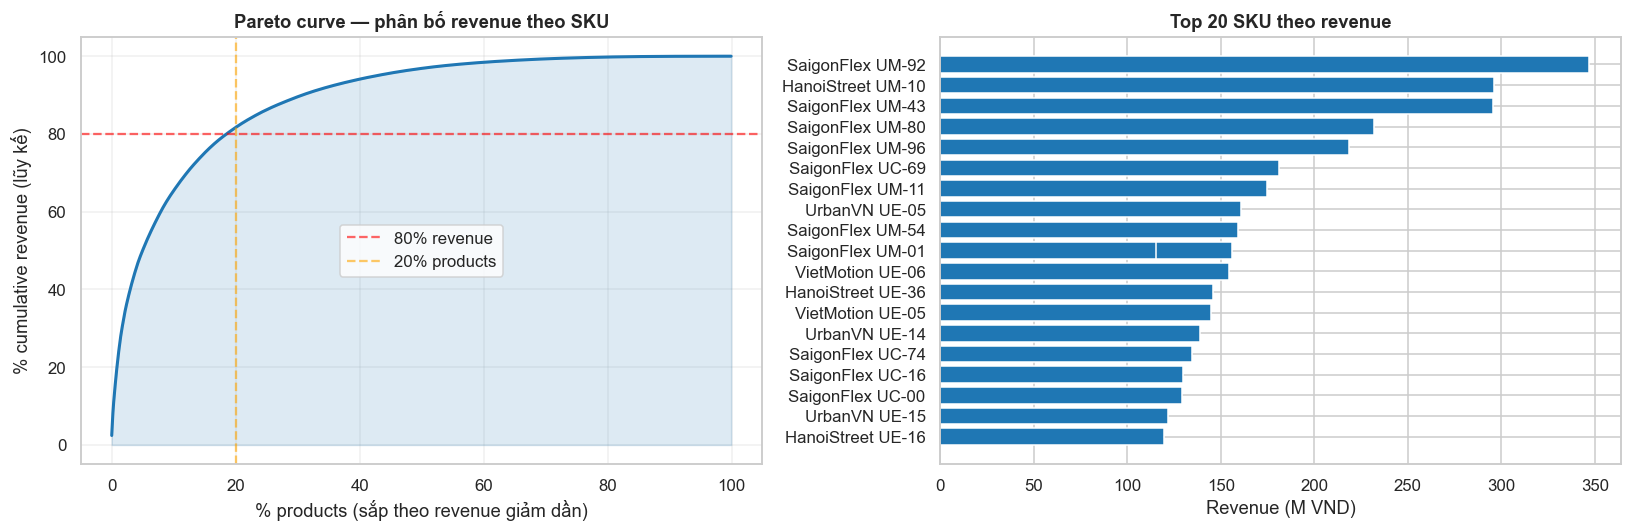


Slow movers (95-100% cumulative tail): 906 SKU = 57.2% catalog → chỉ tạo 5% revenue
  → Cân nhắc tinh giảm. Tổng revenue: 0.71B VND


In [26]:
prod_summary = (oi_valid.groupby(['product_id','product_name','category','segment'])
                .agg(revenue=('net_revenue','sum'),
                     profit=('gross_profit','sum'),
                     units=('quantity','sum'))
                .reset_index()
                .assign(margin_pct=lambda d: d['profit']/d['revenue']*100)
                .sort_values('revenue', ascending=False)
                .reset_index(drop=True))

prod_summary['rev_pct_cum'] = prod_summary['revenue'].cumsum() / prod_summary['revenue'].sum() * 100
total_prods = len(prod_summary)
print(f'Tổng số SKU: {total_prods:,}')
print(f'\n% products để đạt cumulative revenue threshold:')
for threshold in [50, 80, 95]:
    n = (prod_summary['rev_pct_cum'] <= threshold).sum() + 1
    pct = n / total_prods * 100
    print(f'  {threshold:>3}% revenue ← từ top {n:>5,} products ({pct:>5.1f}% catalog)')

# Pareto curve
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
x_pct = np.arange(total_prods)/total_prods*100
ax.plot(x_pct, prod_summary['rev_pct_cum'], lw=2, color='#1f77b4')
ax.axhline(80, color='red', ls='--', alpha=0.6, label='80% revenue')
ax.axvline(20, color='orange', ls='--', alpha=0.6, label='20% products')
ax.fill_between(x_pct, 0, prod_summary['rev_pct_cum'], alpha=0.15, color='#1f77b4')
ax.set_xlabel('% products (sắp theo revenue giảm dần)')
ax.set_ylabel('% cumulative revenue (lũy kế)')
ax.set_title('Pareto curve — phân bố revenue theo SKU')
ax.legend(); ax.grid(alpha=0.3)

# Top 20 SKU bar
ax = axes[1]
top20 = prod_summary.head(20)
ax.barh(top20['product_name'], top20['revenue']/1e6, color='#1f77b4')
ax.set_title('Top 20 SKU theo revenue')
ax.set_xlabel('Revenue (M VND)')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

# Bottom slow movers
slow_movers = prod_summary[prod_summary['rev_pct_cum'] >= 95]
print(f'\nSlow movers (95-100% cumulative tail): {len(slow_movers):,} SKU = {len(slow_movers)/total_prods*100:.1f}% catalog → chỉ tạo 5% revenue')
print(f'  → Cân nhắc tinh giảm. Tổng revenue: {slow_movers["revenue"].sum()/1e9:.2f}B VND')

### 🔍 4.3 Volume × Margin matrix (BCG-style)

**Khung phân tích BCG (Boston Consulting Group):** chia sản phẩm thành 4 góc dựa trên 2 chiều:
- **⭐ Stars (Ngôi sao):** revenue cao + margin cao → giữ và đẩy mạnh
- **💰 Cash Cows (Bò sữa):** margin cao, revenue thấp → tăng visibility / promotion
- **? Question Marks (Dấu hỏi):** revenue cao, margin thấp → review pricing hoặc cost
- **🐕 Dogs (Chó):** thấp cả 2 chiều → cân nhắc cắt bỏ

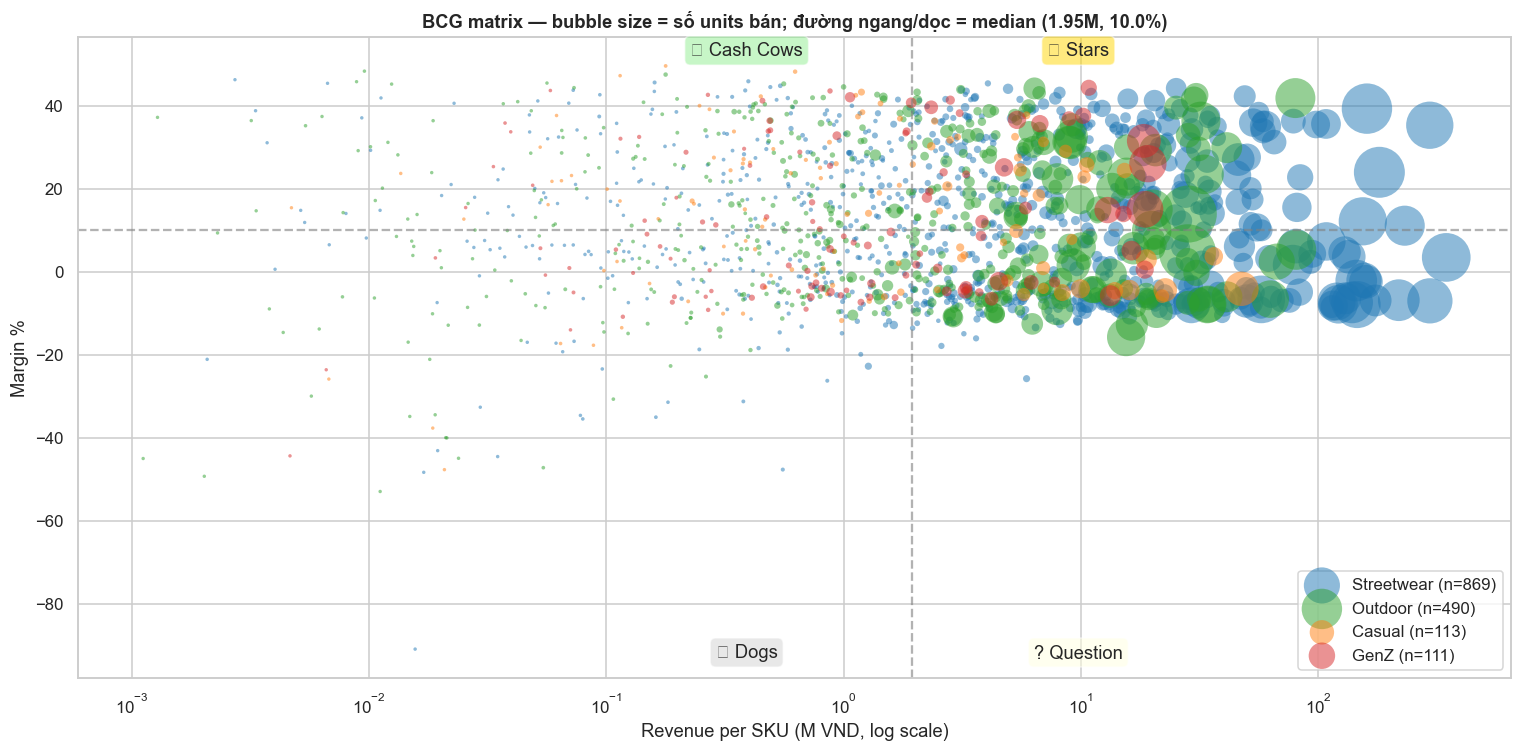

Quadrant summary:
                  n_products    total_revenue     total_profit  avg_margin  rev_share  profit_share
quadrant                                                                                           
? Question Marks         412 8,012,086,328.05  -233,181,254.20       -2.91      56.29        -16.92
⭐ Stars                  380 5,774,988,929.04 1,552,737,180.89       26.89      40.57        112.70
🐕 Dogs                   379   207,491,505.18    -5,245,175.04       -2.53       1.46         -0.38
💰 Cash Cows              412   239,288,865.73    63,431,640.85       26.51       1.68          4.60


In [27]:
median_rev = prod_summary['revenue'].median() / 1e6  # M VND
median_mar = prod_summary['margin_pct'].median()

# Quadrant tag
def quad(row):
    high_rev = (row['revenue']/1e6) >= median_rev
    high_mar = row['margin_pct'] >= median_mar
    if high_rev and high_mar: return '⭐ Stars'
    if high_rev and not high_mar: return '? Question Marks'
    if not high_rev and high_mar: return '💰 Cash Cows'
    return '🐕 Dogs'
prod_summary['quadrant'] = prod_summary.apply(quad, axis=1)

# Scatter plot, color theo category
fig, ax = plt.subplots(figsize=(14, 7))
cat_colors = {'Streetwear':'#1f77b4','Outdoor':'#2ca02c','Casual':'#ff7f0e','GenZ':'#d62728'}
for cat, color in cat_colors.items():
    sub = prod_summary[prod_summary['category']==cat]
    ax.scatter(sub['revenue']/1e6, sub['margin_pct'],
               s=sub['units']/30 + 5, alpha=0.5,
               label=f'{cat} (n={len(sub)})', color=color, edgecolors='none')

ax.axvline(median_rev, color='gray', ls='--', alpha=0.6)
ax.axhline(median_mar, color='gray', ls='--', alpha=0.6)

# Quadrant labels
ax.text(median_rev*5, ax.get_ylim()[1]*0.92, '⭐ Stars', fontsize=12, ha='center',
        bbox=dict(boxstyle='round', facecolor='gold', alpha=0.5))
ax.text(median_rev*0.2, ax.get_ylim()[1]*0.92, '💰 Cash Cows', fontsize=12, ha='center',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
ax.text(median_rev*0.2, ax.get_ylim()[0]+5, '🐕 Dogs', fontsize=12, ha='center',
        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))
ax.text(median_rev*5, ax.get_ylim()[0]+5, '? Question', fontsize=12, ha='center',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

ax.set_xscale('log')
ax.set_xlabel('Revenue per SKU (M VND, log scale)')
ax.set_ylabel('Margin %')
ax.set_title(f'BCG matrix — bubble size = số units bán; đường ngang/dọc = median ({median_rev:.2f}M, {median_mar:.1f}%)')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

# Quadrant counts
quad_summary = (prod_summary.groupby('quadrant')
                .agg(n_products=('product_id','count'),
                     total_revenue=('revenue','sum'),
                     total_profit=('profit','sum'))
                .assign(avg_margin=lambda d: d['total_profit']/d['total_revenue']*100,
                        rev_share=lambda d: d['total_revenue']/d['total_revenue'].sum()*100,
                        profit_share=lambda d: d['total_profit']/d['total_profit'].sum()*100))
print('Quadrant summary:')
print(quad_summary.to_string())

### 🔍 4.4 Diagnostic — Category trend qua năm

**Câu hỏi:** category nào tụt mạnh nhất giai đoạn 2016→2022, đóng góp gì cho tụt 50% revenue toàn công ty?

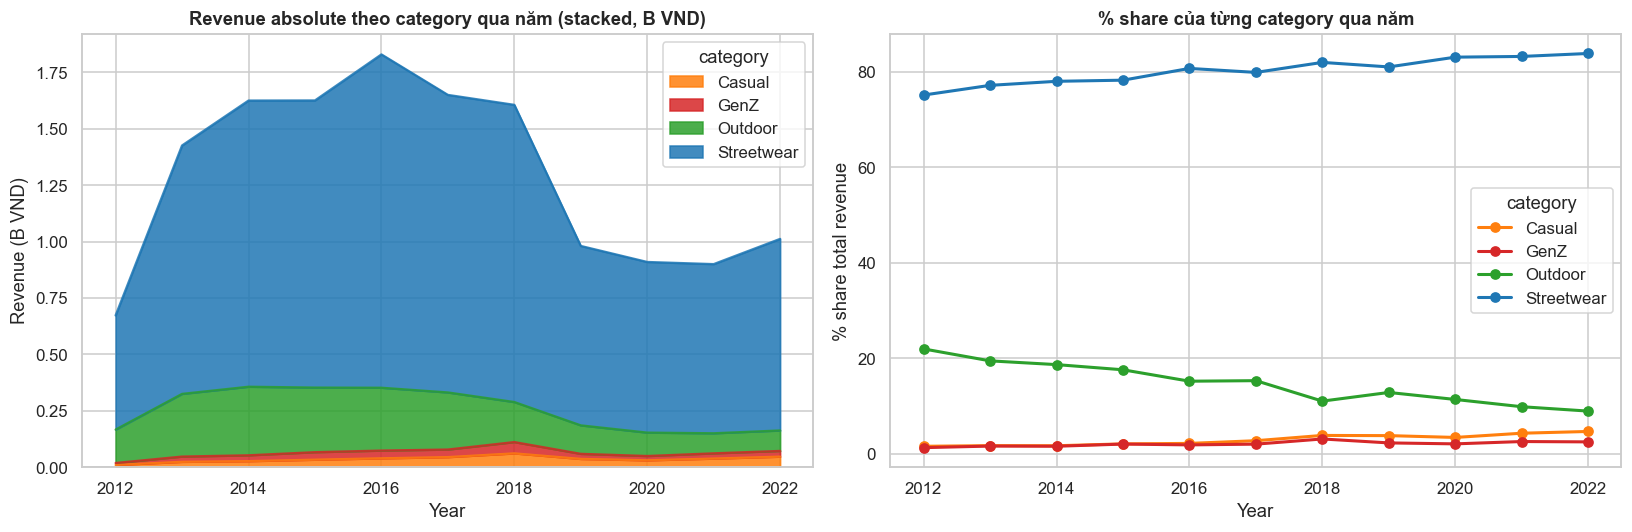

Peak + decline mỗi category:
            peak_year     peak_revenue   last_revenue  decline_from_peak_pct
category                                                                    
Casual           2018    61,952,784.51  47,449,157.05                 -23.41
GenZ             2018    50,069,261.18  25,381,862.60                 -49.31
Outdoor          2014   303,610,647.93  90,619,556.36                 -70.15
Streetwear       2016 1,476,175,610.93 848,434,104.76                 -42.52


In [28]:
cat_yearly = oi_valid.groupby(['order_year','category'])['net_revenue'].sum().unstack(fill_value=0)
cat_yearly_pct = cat_yearly.div(cat_yearly.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
(cat_yearly/1e9).plot.area(ax=axes[0], stacked=True, alpha=0.85,
                            color=[cat_colors[c] for c in cat_yearly.columns])
axes[0].set_title('Revenue absolute theo category qua năm (stacked, B VND)')
axes[0].set_ylabel('Revenue (B VND)')
axes[0].set_xlabel('Year')

cat_yearly_pct.plot(ax=axes[1], marker='o', lw=2,
                    color=[cat_colors[c] for c in cat_yearly_pct.columns])
axes[1].set_title('% share của từng category qua năm')
axes[1].set_ylabel('% share total revenue')
axes[1].set_xlabel('Year')
plt.tight_layout(); plt.show()

# Decline per category
cat_decline = pd.DataFrame({
    'peak_year':    cat_yearly.idxmax(),
    'peak_revenue': cat_yearly.max(),
    'last_revenue': cat_yearly.iloc[-1],
}).assign(decline_from_peak_pct=lambda d: (d['last_revenue']/d['peak_revenue'] - 1)*100)
print('Peak + decline mỗi category:')
print(cat_decline.to_string())

### 🔮 4.5 Predictive — Stay-or-cut analysis (giữ hay cắt)

**Phép tính:** nếu cắt bottom 50% SKU (phân nửa catalog), mất bao nhiêu revenue/profit nhưng tiết kiệm được gì?

Tinh giảm catalog (SKU rationalization) là chiến lược phổ biến: tập trung bán hàng/marketing/tồn kho cho top performers thay vì dàn trải.

In [29]:
# Cắt bottom 50% theo revenue
cutoff = prod_summary['revenue'].median()
bottom_half = prod_summary[prod_summary['revenue'] < cutoff]
top_half    = prod_summary[prod_summary['revenue'] >= cutoff]

bottom_rev_share = bottom_half['revenue'].sum() / prod_summary['revenue'].sum() * 100
top_rev_share    = top_half['revenue'].sum()    / prod_summary['revenue'].sum() * 100
bottom_prof_share = bottom_half['profit'].sum() / prod_summary['profit'].sum() * 100
top_prof_share    = top_half['profit'].sum()    / prod_summary['profit'].sum() * 100

print(f'Bottom 50% catalog ({len(bottom_half):,} SKU):')
print(f'  Revenue: {bottom_half["revenue"].sum()/1e9:.2f}B ({bottom_rev_share:.1f}% tổng)')
print(f'  Profit:  {bottom_half["profit"].sum()/1e9:.2f}B ({bottom_prof_share:.1f}% tổng)')
print(f'\nTop 50% catalog ({len(top_half):,} SKU):')
print(f'  Revenue: {top_half["revenue"].sum()/1e9:.2f}B ({top_rev_share:.1f}% tổng)')
print(f'  Profit:  {top_half["profit"].sum()/1e9:.2f}B ({top_prof_share:.1f}% tổng)')

# Margin losers (dưới 10%)
margin_losers = prod_summary[prod_summary['margin_pct'] < 10]
print(f'\nLow-margin SKU (margin < 10%): {len(margin_losers):,} ({len(margin_losers)/len(prod_summary)*100:.1f}% catalog)')
if len(margin_losers) > 0:
    print(f'  Revenue: {margin_losers["revenue"].sum()/1e9:.2f}B ({margin_losers["revenue"].sum()/prod_summary["revenue"].sum()*100:.1f}% tổng)')
    print(f'  Profit:  {margin_losers["profit"].sum()/1e9:.2f}B (~tương đương 0)')

Bottom 50% catalog (791 SKU):
  Revenue: 0.45B (3.1% tổng)
  Profit:  0.06B (4.2% tổng)

Top 50% catalog (792 SKU):
  Revenue: 13.79B (96.9% tổng)
  Profit:  1.32B (95.8% tổng)

Low-margin SKU (margin < 10%): 791 (50.0% catalog)
  Revenue: 8.22B (57.7% tổng)
  Profit:  -0.24B (~tương đương 0)


### 🎯 4.6 Prescriptive — Đề xuất hành động + ước tính impact

In [30]:
# Pull key numbers
top_cat       = cat_summary.index[0]
top_cat_rev   = cat_summary.iloc[0]['revenue']
top_seg       = seg_summary4['margin_pct'].idxmax()
top_seg_margin = seg_summary4.loc[top_seg, 'margin_pct']
worst_cat     = cat_decline['decline_from_peak_pct'].idxmin()
worst_cat_decline = cat_decline.loc[worst_cat, 'decline_from_peak_pct']
n_dogs        = (prod_summary['quadrant']=='🐕 Dogs').sum()
dog_revenue   = prod_summary[prod_summary['quadrant']=='🐕 Dogs']['revenue'].sum()
dog_profit    = prod_summary[prod_summary['quadrant']=='🐕 Dogs']['profit'].sum()
n_stars       = (prod_summary['quadrant']=='⭐ Stars').sum()
star_revenue  = prod_summary[prod_summary['quadrant']=='⭐ Stars']['revenue'].sum()

# Inventory carry cost ước tính ~20% giá vốn/năm cho slow movers
n_slow = len(slow_movers)
# Giả định mỗi SKU slow mover tốn carrying cost ~0.5M VND/năm (chi phí kho + opportunity cost)
carry_savings = n_slow * 500_000

recs4 = [
    {
        'rank': 1,
        'action': f'Cắt {n_slow:,} slow-mover SKU (5% tail revenue) — focus shelf/marketing/stock vào top performers',
        'rationale': f'Bottom 5% revenue tail = {n_slow:,} SKU/{total_prods:,} ({n_slow/total_prods*100:.1f}%). Mỗi SKU ngậm carrying cost (chi phí ngậm vốn + lưu kho) mà revenue đóng góp không bù',
        'estimated_impact': f'Tiết kiệm ước {carry_savings/1e9:.2f}B VND/năm carrying cost (giả định 0.5M/SKU/năm)',
    },
    {
        'rank': 2,
        'action': f'Đẩy mạnh {n_stars:,} Stars products — tăng visibility, đảm bảo stock, cross-sell',
        'rationale': f'Stars đóng góp {star_revenue/prod_summary["revenue"].sum()*100:.0f}% revenue dù chỉ {n_stars/total_prods*100:.0f}% catalog. Push thêm 5% volume = lift đáng kể',
        'estimated_impact': f'Stars +5% volume = +{0.05*star_revenue/1e9:.2f}B VND/năm',
    },
    {
        'rank': 3,
        'action': f'Cứu category {worst_cat} — đã tụt {worst_cat_decline:.0f}% từ peak, đe doạ portfolio',
        'rationale': f'{worst_cat} là category tụt nhanh nhất. Có thể do trend (xu hướng) thay đổi hoặc product fit yếu. Cần research nhu cầu thị trường + refresh design',
        'estimated_impact': f'Recovery 30% gap {worst_cat} = +{0.30 * (cat_decline.loc[worst_cat,"peak_revenue"] - cat_decline.loc[worst_cat,"last_revenue"])/1e9:.2f}B VND/năm',
    },
    {
        'rank': 4,
        'action': f'Review pricing Question Marks (revenue cao, margin thấp) — thử nâng giá 5% hoặc giảm cost',
        'rationale': f'? Question Marks bán nhiều mà ít lời. {(prod_summary["quadrant"]=="? Question Marks").sum()} SKU thuộc nhóm này — có dư địa nâng giá nhẹ mà không mất volume',
        'estimated_impact': f'Nâng margin 2pp cho ? Question = +{0.02 * prod_summary[prod_summary["quadrant"]=="? Question Marks"]["revenue"].sum()/1e9:.2f}B VND/năm',
    },
]

recs4_df = pd.DataFrame(recs4)
print(recs4_df.to_string(index=False))

for r in recs4:
    RECOMMENDATIONS.append({'section': 'Product / Category', **r})

print(f'\n✅ Section 4 đóng góp {len(recs4)} đề xuất vào executive summary')

 rank                                                                                    action                                                                                                                                      rationale                                                  estimated_impact
    1 Cắt 906 slow-mover SKU (5% tail revenue) — focus shelf/marketing/stock vào top performers           Bottom 5% revenue tail = 906 SKU/1,583 (57.2%). Mỗi SKU ngậm carrying cost (chi phí ngậm vốn + lưu kho) mà revenue đóng góp không bù Tiết kiệm ước 0.45B VND/năm carrying cost (giả định 0.5M/SKU/năm)
    2                  Đẩy mạnh 380 Stars products — tăng visibility, đảm bảo stock, cross-sell                                                              Stars đóng góp 41% revenue dù chỉ 24% catalog. Push thêm 5% volume = lift đáng kể                                 Stars +5% volume = +0.29B VND/năm
    3                              Cứu category Outdoor — đã tụt -70% từ peak, đe doạ

## <a id='s5'></a>Section 5 — Promotion Effectiveness

> **Câu hỏi kinh doanh:** Promo nào thực sự lift sales (tạo doanh thu vượt baseline), promo nào burn budget (đốt ngân sách giảm giá mà không lift)? Section 1 đã flag rằng outliers chỉ 0.88× baseline trùng promo — section này đi sâu từng promo cụ thể.

### 📊 5.1 Descriptive — Tổng quan 50 promo

In [31]:
promo_overview = (promotions
                  .assign(days=lambda d: (d['end_date'] - d['start_date']).dt.days,
                          year=lambda d: d['start_date'].dt.year))
print('Phân bố promo theo năm:')
print(promo_overview.groupby('year').size().to_string())
print('\nPhân bố theo type & channel:')
print(promo_overview.groupby(['promo_type','promo_channel']).size().to_string())
print('\nĐộ dài promo (ngày):')
print(promo_overview['days'].describe().to_string())

# Promo usage in order_items
total_oi = len(order_items)
with_promo = order_items['promo_id'].notna().sum()
total_discount_given = order_items['discount_amount'].sum()
print(f'\nOrder_items có promo_id: {with_promo:,} / {total_oi:,} ({with_promo/total_oi*100:.1f}%)')
print(f'Tổng discount đã cho: {total_discount_given/1e9:.2f}B VND')

Phân bố promo theo năm:
year
2013    6
2014    4
2015    6
2016    4
2017    6
2018    4
2019    6
2020    4
2021    6
2022    4

Phân bố theo type & channel:
promo_type  promo_channel
fixed       online            5
percentage  all_channels     19
            email             7
            in_store          5
            online            8
            social_media      6

Độ dài promo (ngày):
count   50.00
mean    33.54
std      5.81
min     29.00
25%     30.00
50%     30.50
75%     34.00
max     45.00

Order_items có promo_id: 276,316 / 714,669 (38.7%)
Tổng discount đã cho: 0.75B VND


### 🔍 5.2 Diagnostic — Lift analysis từng promo

**Lift (mức tăng đột biến)** = (Revenue trong promo window) − (Expected baseline)

Với mỗi promo, tính baseline = avg daily revenue **30 ngày trước + 30 ngày sau** promo window. Nếu lift > 0 = promo có hiệu quả; nếu ≤ 0 = promo thất bại.

In [32]:
promo_lift_rows = []
for _, p in promotions.iterrows():
    window = (sales['Date'] >= p['start_date']) & (sales['Date'] <= p['end_date'])
    days = int(window.sum())
    if days == 0:
        continue
    rev_during = sales.loc[window, 'Revenue'].sum()
    pre_w  = (sales['Date'] >= p['start_date'] - pd.Timedelta(days=30)) & (sales['Date'] < p['start_date'])
    post_w = (sales['Date'] > p['end_date']) & (sales['Date'] <= p['end_date'] + pd.Timedelta(days=30))
    baseline_pool = pd.concat([sales.loc[pre_w,'Revenue'], sales.loc[post_w,'Revenue']])
    if len(baseline_pool) == 0:
        continue
    baseline_daily = baseline_pool.mean()
    expected = baseline_daily * days
    promo_lift_rows.append({
        'promo_id': p['promo_id'], 'promo_name': p['promo_name'],
        'promo_type': p['promo_type'], 'discount_value': p['discount_value'],
        'channel': p['promo_channel'], 'days': days,
        'rev_during': rev_during, 'expected': expected,
        'lift_abs': rev_during - expected,
        'lift_pct': (rev_during/expected - 1) * 100 if expected > 0 else None,
    })

promo_lift_df = pd.DataFrame(promo_lift_rows)

# Merge với discount cost từ order_items
promo_disc = (oi_valid[oi_valid['promo_id'].notna()]
              .groupby('promo_id')
              .agg(total_discount=('discount_amount','sum'),
                   units_promoted=('quantity','sum'),
                   orders_promoted=('order_id','nunique'))
              .reset_index())
promo_full = promo_lift_df.merge(promo_disc, on='promo_id', how='left').fillna({'total_discount':0,'units_promoted':0,'orders_promoted':0})
promo_full['net_value'] = promo_full['lift_abs'] - promo_full['total_discount']
promo_full['roi_x']     = np.where(promo_full['total_discount']>0,
                                   promo_full['lift_abs'] / promo_full['total_discount'],
                                   np.nan)

# Sort by net_value desc
promo_full = promo_full.sort_values('net_value', ascending=False)
print('Top 10 promo theo Net Value (lift − discount cost):')
print(promo_full[['promo_name','days','lift_abs','total_discount','net_value','lift_pct','roi_x']].head(10).to_string(index=False))
print('\nBottom 10 promo (đốt budget):')
print(promo_full[['promo_name','days','lift_abs','total_discount','net_value','lift_pct','roi_x']].tail(10).to_string(index=False))

# Aggregate
n_winners = (promo_full['net_value'] > 0).sum()
n_losers  = (promo_full['net_value'] <= 0).sum()
total_lift = promo_full['lift_abs'].sum()
total_disc = promo_full['total_discount'].sum()
total_net  = promo_full['net_value'].sum()
print(f'\n=== Aggregate {len(promo_full)} promo ===')
print(f'Winners (net > 0):  {n_winners}')
print(f'Losers  (net ≤ 0):  {n_losers}')
print(f'Tổng lift:          {total_lift/1e9:+.2f}B VND')
print(f'Tổng discount cost: {total_disc/1e9:.2f}B VND')
print(f'Tổng net value:     {total_net/1e9:+.2f}B VND')

Top 10 promo theo Net Value (lift − discount cost):
      promo_name  days      lift_abs  total_discount     net_value  lift_pct  roi_x
Fall Launch 2015    33 39,824,697.52   13,819,876.32 26,004,821.20     29.34   2.88
Spring Sale 2020    31 36,205,912.99   13,675,067.32 22,530,845.67     34.03   2.65
Spring Sale 2022    31 27,230,901.98   14,456,576.31 12,774,325.67     21.90   1.88
Fall Launch 2013    34 24,148,158.00   11,955,821.68 12,192,336.32     19.09   2.02
Spring Sale 2021    31 24,535,367.01   13,018,448.31 11,516,918.70     21.75   1.88
Fall Launch 2019    33 16,995,502.57    7,397,146.03  9,598,356.54     21.25   2.30
Fall Launch 2021    34 14,634,406.24    6,710,784.49  7,923,621.75     19.99   2.18
Spring Sale 2017    31 30,069,440.27   22,301,183.90  7,768,256.37     15.19   1.35
Fall Launch 2017    34 18,594,732.19   11,687,611.46  6,907,120.73     13.46   1.59
Spring Sale 2015    31 27,405,185.77   21,766,090.54  5,639,095.23     13.77   1.26

Bottom 10 promo (đốt bu

### 🔍 5.3 Phân loại winners vs losers — biểu đồ trực quan

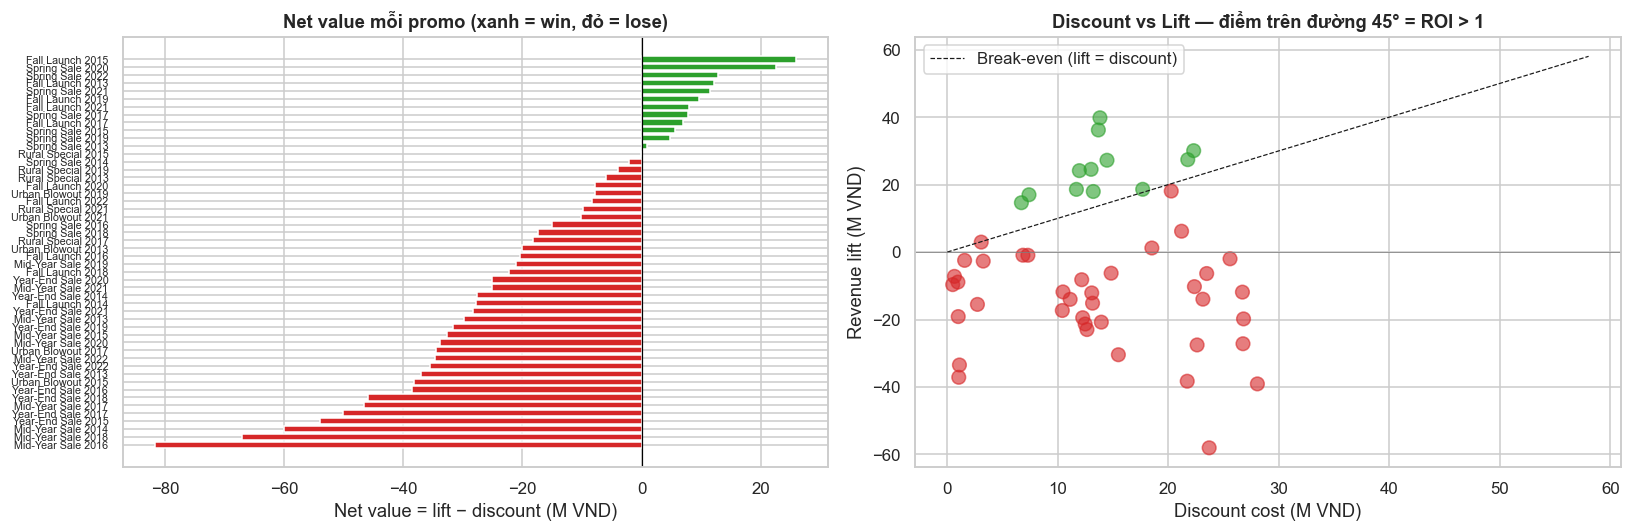

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
colors_pl = ['#2ca02c' if v > 0 else '#d62728' for v in promo_full['net_value']]
ax.barh(range(len(promo_full)), promo_full['net_value']/1e6, color=colors_pl)
ax.set_yticks(range(len(promo_full)))
ax.set_yticklabels(promo_full['promo_name'], fontsize=7)
ax.invert_yaxis()
ax.set_xlabel('Net value = lift − discount (M VND)')
ax.set_title('Net value mỗi promo (xanh = win, đỏ = lose)')
ax.axvline(0, color='black', lw=0.8)

ax = axes[1]
ax.scatter(promo_full['total_discount']/1e6, promo_full['lift_abs']/1e6,
           c=colors_pl, s=80, alpha=0.6)
mx = max(promo_full['total_discount'].max(), promo_full['lift_abs'].abs().max())/1e6
ax.plot([0, mx], [0, mx], 'k--', lw=0.8, label='Break-even (lift = discount)')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel('Discount cost (M VND)')
ax.set_ylabel('Revenue lift (M VND)')
ax.set_title('Discount vs Lift — điểm trên đường 45° = ROI > 1')
ax.legend()
plt.tight_layout(); plt.show()

### 🔮 5.4 Predictive — Nếu kill toàn bộ promo losers, save bao nhiêu?

In [34]:
losers = promo_full[promo_full['net_value'] <= 0]
saving_if_killed = losers['total_discount'].sum() - losers['lift_abs'].sum()
print(f'Số promo losers: {len(losers)}')
print(f'Tổng discount cost cho losers: {losers["total_discount"].sum()/1e9:.2f}B VND')
print(f'Tổng lift losers tạo ra: {losers["lift_abs"].sum()/1e9:+.2f}B VND')
print(f'\n→ Nếu kill toàn bộ losers, tiết kiệm: {saving_if_killed/1e9:.2f}B VND tổng (qua nhiều năm)')

years_span = (sales['Date'].max() - sales['Date'].min()).days / 365.25
saving_per_year = saving_if_killed / years_span
print(f'  Per year average: {saving_per_year/1e9:.2f}B VND/năm')

Số promo losers: 38
Tổng discount cost cho losers: 0.51B VND
Tổng lift losers tạo ra: -0.56B VND

→ Nếu kill toàn bộ losers, tiết kiệm: 1.08B VND tổng (qua nhiều năm)
  Per year average: 0.10B VND/năm


### 🎯 5.5 Prescriptive — Đề xuất hành động

In [35]:
top_promos = promo_full.head(5)['promo_name'].tolist()

recs5 = [
    {
        'rank': 1,
        'action': f'Kill {n_losers} promo losers (net ≤ 0) — tiết kiệm cost mà không mất doanh thu',
        'rationale': f'Losers đốt {losers["total_discount"].sum()/1e9:.2f}B discount nhưng chỉ tạo {losers["lift_abs"].sum()/1e9:+.2f}B lift. Net loss = {(saving_if_killed)/1e9:.2f}B trên toàn bộ data',
        'estimated_impact': f'+{saving_per_year/1e9:.2f}B VND/năm (saving đều qua các năm)',
    },
    {
        'rank': 2,
        'action': f'Nhân rộng top 5 promo winners — {", ".join(top_promos[:3])}...',
        'rationale': f'5 promo này đem lại net positive lớn nhất. Phân tích đặc điểm chung (timing, channel, discount %) để thiết kế campaign mới',
        'estimated_impact': f'Replication +20% lift winners = +{0.20 * promo_full.head(5)["lift_abs"].sum() / years_span / 1e9:.2f}B VND/năm',
    },
    {
        'rank': 3,
        'action': 'Sửa lại quy trình duyệt promo — A/B test trước khi rollout, KPI = net value chứ không phải gross sales',
        'rationale': f'{n_losers}/{len(promo_full)} promo ({n_losers/len(promo_full)*100:.0f}%) failed → process duyệt promo có vấn đề. Cần guardrail rõ ràng',
        'estimated_impact': 'Giảm 50% promo losers tương lai = quy trình hoá saving (cần đo sau khi triển khai)',
    },
]

recs5_df = pd.DataFrame(recs5)
print(recs5_df.to_string(index=False))

for r in recs5:
    RECOMMENDATIONS.append({'section': 'Promotion Effectiveness', **r})

print(f'\n✅ Section 5 đóng góp {len(recs5)} đề xuất')

 rank                                                                                                 action                                                                                                                  rationale                                                                   estimated_impact
    1                                 Kill 38 promo losers (net ≤ 0) — tiết kiệm cost mà không mất doanh thu                                    Losers đốt 0.51B discount nhưng chỉ tạo -0.56B lift. Net loss = 1.08B trên toàn bộ data                                            +0.10B VND/năm (saving đều qua các năm)
    2                Nhân rộng top 5 promo winners — Fall Launch 2015, Spring Sale 2020, Spring Sale 2022... 5 promo này đem lại net positive lớn nhất. Phân tích đặc điểm chung (timing, channel, discount %) để thiết kế campaign mới                                     Replication +20% lift winners = +0.00B VND/năm
    3 Sửa lại quy trình duyệt promo — A/B test trước kh

## <a id='s6'></a>Section 6 — Returns & Quality Loss

> **Câu hỏi kinh doanh:** wrong_size chiếm 35% returns Streetwear (từ MCQ Q3). Fix size guide tiết kiệm bao nhiêu? Sản phẩm nào return rate quá cao cần loại?

### 📊 6.1 Descriptive — Return rate (tỷ lệ trả hàng) theo nhiều chiều

Return rate = `Σ return_quantity / Σ quantity sold` cho cùng nhóm.

Tổng refund: 0.51B VND (3.59% revenue)
Tổng return events: 39,939, return_quantity tổng: 109,586


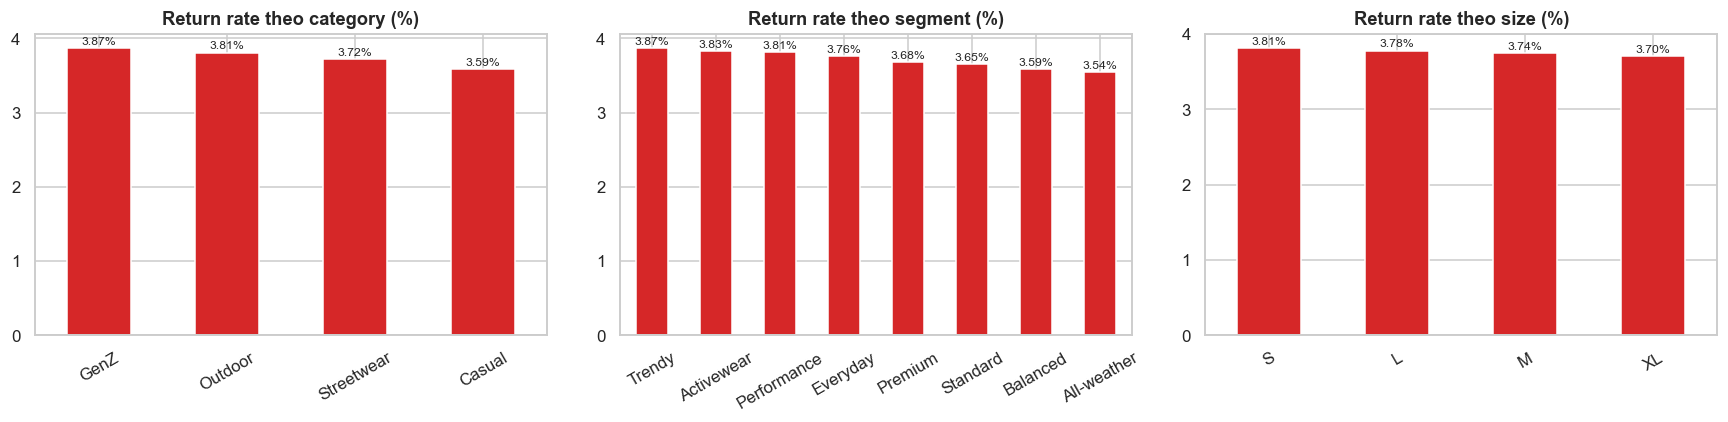

In [36]:
sold_cat  = oi_valid.groupby('category')['quantity'].sum()
sold_seg  = oi_valid.groupby('segment')['quantity'].sum()
sold_size = oi_valid.groupby('size')['quantity'].sum()

ret_full = returns.merge(products[['product_id','category','segment','size','color','product_name']], on='product_id', how='left')
returned_cat  = ret_full.groupby('category')['return_quantity'].sum()
returned_seg  = ret_full.groupby('segment')['return_quantity'].sum()
returned_size = ret_full.groupby('size')['return_quantity'].sum()

rate_cat  = (returned_cat  / sold_cat  * 100).fillna(0).sort_values(ascending=False)
rate_seg  = (returned_seg  / sold_seg  * 100).fillna(0).sort_values(ascending=False)
rate_size = (returned_size / sold_size * 100).fillna(0).sort_values(ascending=False)

total_refund = returns['refund_amount'].sum()
total_revenue_all = oi_valid['net_revenue'].sum()
print(f'Tổng refund: {total_refund/1e9:.2f}B VND ({total_refund/total_revenue_all*100:.2f}% revenue)')
print(f'Tổng return events: {len(returns):,}, return_quantity tổng: {returns["return_quantity"].sum():,}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
rate_cat.plot.bar(ax=axes[0], color='#d62728')
axes[0].set_title('Return rate theo category (%)')
for i,v in enumerate(rate_cat): axes[0].text(i,v+0.05,f'{v:.2f}%',ha='center',fontsize=8)

rate_seg.plot.bar(ax=axes[1], color='#d62728')
axes[1].set_title('Return rate theo segment (%)')
for i,v in enumerate(rate_seg): axes[1].text(i,v+0.05,f'{v:.2f}%',ha='center',fontsize=8)

rate_size.plot.bar(ax=axes[2], color='#d62728')
axes[2].set_title('Return rate theo size (%)')
for i,v in enumerate(rate_size): axes[2].text(i,v+0.05,f'{v:.2f}%',ha='center',fontsize=8)

for a in axes:
    a.set_xlabel('')
    a.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

### 🔍 6.2 Diagnostic — Reason breakdown + cost mỗi nguyên nhân

Return reasons (sắp theo tổng refund):
                  n_events    qty         refund  pct_events  pct_refund  avg_refund
return_reason                                                                       
wrong_size           13967  38042 176,687,200.75       34.97       34.60   12,650.33
defective             8020  22274 103,599,143.26       20.08       20.29   12,917.60
not_as_described      7035  19358  90,653,190.78       17.61       17.75   12,886.03
changed_mind          6931  19144  89,721,759.00       17.35       17.57   12,944.99
late_delivery         3986  10768  49,937,212.76        9.98        9.78   12,528.15


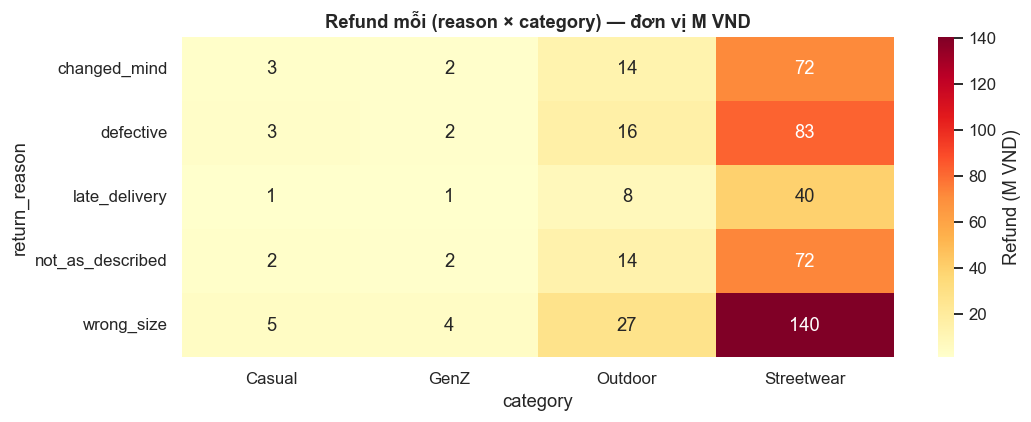

In [37]:
reason_summary = (returns.groupby('return_reason')
                  .agg(n_events=('return_id','count'),
                       qty=('return_quantity','sum'),
                       refund=('refund_amount','sum'))
                  .assign(pct_events=lambda d: d['n_events']/d['n_events'].sum()*100,
                          pct_refund=lambda d: d['refund']/d['refund'].sum()*100,
                          avg_refund=lambda d: d['refund']/d['n_events'])
                  .sort_values('refund', ascending=False))
print('Return reasons (sắp theo tổng refund):')
print(reason_summary.to_string())

reason_cat = (ret_full.groupby(['return_reason','category'])['refund_amount']
              .sum().unstack(fill_value=0))
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(reason_cat/1e6, annot=True, fmt='.0f', cmap='YlOrRd',
            cbar_kws={'label':'Refund (M VND)'}, ax=ax)
ax.set_title('Refund mỗi (reason × category) — đơn vị M VND')
plt.tight_layout(); plt.show()

### 🔍 6.3 Top SKU theo refund cost — sản phẩm cần review chất lượng

In [38]:
prod_returns = (ret_full.groupby(['product_id','product_name','category'])
                .agg(n_returns=('return_id','count'),
                     qty_returned=('return_quantity','sum'),
                     refund=('refund_amount','sum'))
                .reset_index())
prod_sold_qty = oi_valid.groupby('product_id')['quantity'].sum().rename('units_sold')
prod_returns = prod_returns.merge(prod_sold_qty, on='product_id', how='left')
prod_returns['return_rate'] = prod_returns['qty_returned'] / prod_returns['units_sold'] * 100
prod_returns = prod_returns.sort_values('refund', ascending=False)

top_loss = prod_returns.head(10)
print('Top 10 SKU theo refund cost:')
print(top_loss.to_string(index=False))

ret_with_order = returns.merge(orders[['order_id','order_date']], on='order_id', how='left')
ret_with_order['days_to_return'] = (ret_with_order['return_date'] - ret_with_order['order_date']).dt.days
ttr = ret_with_order['days_to_return'].dropna()
print(f'\nTime-to-return distribution:')
print(ttr.describe().to_string())

Top 10 SKU theo refund cost:
 product_id      product_name   category  n_returns  qty_returned        refund  units_sold  return_rate
        487  SaigonFlex UM-92 Streetwear        415          1129 12,241,878.26       30355         3.72
        826 HanoiStreet UM-10 Streetwear        360           996 10,879,460.50       26180         3.80
        438  SaigonFlex UM-43 Streetwear        375           971  9,654,909.83       28614         3.39
        475  SaigonFlex UM-80 Streetwear        265           733  7,958,581.64       20518         3.57
        491  SaigonFlex UM-96 Streetwear        273           754  7,121,041.39       22248         3.39
        604  SaigonFlex UC-69 Streetwear        441          1169  6,113,477.47       33257         3.52
       2331  VietMotion UE-05 Streetwear        340           935  5,868,240.11       22156         4.22
        609  SaigonFlex UC-74 Streetwear        217           638  5,729,880.67       14429         4.42
       2332  VietMotion UE

### 🔮 6.4 Predictive — Tiết kiệm gì nếu fix size guide?

In [39]:
wrong_size_qty = reason_summary.loc['wrong_size','qty'] if 'wrong_size' in reason_summary.index else 0
wrong_size_refund = reason_summary.loc['wrong_size','refund'] if 'wrong_size' in reason_summary.index else 0

saved_refund_50 = wrong_size_refund * 0.5
saved_refund_70 = wrong_size_refund * 0.7

years_data = (sales['Date'].max() - sales['Date'].min()).days / 365.25
saved_per_year_50 = saved_refund_50 / years_data
saved_per_year_70 = saved_refund_70 / years_data

print(f'wrong_size returns hiện tại: {wrong_size_qty:,} units, refund {wrong_size_refund/1e9:.2f}B VND tổng')
print(f'\nNếu fix size guide giảm 50% wrong_size returns:')
print(f'  Tiết kiệm: {saved_refund_50/1e9:.2f}B VND tổng = {saved_per_year_50/1e9:.2f}B/năm')
print(f'\nNếu giảm 70% (industry best):')
print(f'  Tiết kiệm: {saved_refund_70/1e9:.2f}B VND tổng = {saved_per_year_70/1e9:.2f}B/năm')

defective_refund = reason_summary.loc['defective','refund'] if 'defective' in reason_summary.index else 0
print(f'\ndefective refunds: {defective_refund/1e9:.2f}B VND — cần audit nhà cung cấp')

wrong_size returns hiện tại: 38,042 units, refund 0.18B VND tổng

Nếu fix size guide giảm 50% wrong_size returns:
  Tiết kiệm: 0.09B VND tổng = 0.01B/năm

Nếu giảm 70% (industry best):
  Tiết kiệm: 0.12B VND tổng = 0.01B/năm

defective refunds: 0.10B VND — cần audit nhà cung cấp


### 🎯 6.5 Prescriptive — Đề xuất hành động

In [40]:
late_delivery_n      = reason_summary.loc['late_delivery','n_events'] if 'late_delivery' in reason_summary.index else 0
late_delivery_refund = reason_summary.loc['late_delivery','refund']  if 'late_delivery' in reason_summary.index else 0

recs6 = [
    {
        'rank': 1,
        'action': 'Fix size guide cho category Streetwear (chi tiết hơn, video hướng dẫn đo size)',
        'rationale': f'wrong_size chiếm {reason_summary.loc["wrong_size","pct_events"]:.0f}% events, {reason_summary.loc["wrong_size","pct_refund"]:.0f}% tổng refund. Streetwear bị nặng nhất (size variance cao)',
        'estimated_impact': f'+{saved_per_year_50/1e9:.2f}B VND/năm (giảm 50% wrong_size returns)',
    },
    {
        'rank': 2,
        'action': f'Audit nhà cung cấp cho top 10 SKU defective — refund hiện tại {defective_refund/1e9:.2f}B',
        'rationale': f'defective là reason #2 ({reason_summary.loc["defective","pct_refund"]:.0f}% refund). Một số SKU có return_rate cao bất thường — cần check QC supplier',
        'estimated_impact': f'Giảm 30% defective = +{0.30 * defective_refund / years_data / 1e9:.2f}B/năm',
    },
    {
        'rank': 3,
        'action': 'Cải thiện logistics để giảm late_delivery returns — track on-time delivery KPI',
        'rationale': f'late_delivery returns: {late_delivery_n:,} events. Khách trả vì giao chậm là lỗi vận hành, có thể fix dứt điểm',
        'estimated_impact': f'Giảm 50% late_delivery = +{0.50 * late_delivery_refund / years_data / 1e9:.2f}B/năm',
    },
]

recs6_df = pd.DataFrame(recs6)
print(recs6_df.to_string(index=False))

for r in recs6:
    RECOMMENDATIONS.append({'section': 'Returns & Quality', **r})

print(f'\n✅ Section 6 đóng góp {len(recs6)} đề xuất')

 rank                                                                         action                                                                                             rationale                             estimated_impact
    1 Fix size guide cho category Streetwear (chi tiết hơn, video hướng dẫn đo size)             wrong_size chiếm 35% events, 35% tổng refund. Streetwear bị nặng nhất (size variance cao) +0.01B VND/năm (giảm 50% wrong_size returns)
    2            Audit nhà cung cấp cho top 10 SKU defective — refund hiện tại 0.10B defective là reason #2 (20% refund). Một số SKU có return_rate cao bất thường — cần check QC supplier              Giảm 30% defective = +0.00B/năm
    3 Cải thiện logistics để giảm late_delivery returns — track on-time delivery KPI      late_delivery returns: 3,986 events. Khách trả vì giao chậm là lỗi vận hành, có thể fix dứt điểm          Giảm 50% late_delivery = +0.00B/năm

✅ Section 6 đóng góp 3 đề xuất


## <a id='s7'></a>Section 7 — Inventory Stockout Loss

> **Câu hỏi kinh doanh:** Stockout (out-of-stock — hết hàng) làm mất bao nhiêu doanh thu? Category nào bị nặng nhất? **Lưu ý:** `inventory.csv` là snapshot CUỐI THÁNG, không phải daily — phải xử lý thận trọng.

### 📊 7.1 Descriptive — Tổng quan stockout

In [41]:
print(f'Tổng số snapshot: {len(inventory):,}')
print(f'Date range: {inventory["snapshot_date"].min()} → {inventory["snapshot_date"].max()}')

pct_stockout = inventory['stockout_flag'].mean() * 100
avg_stockout_days = inventory[inventory['stockout_flag']==1]['stockout_days'].mean()
total_stockout_days = inventory['stockout_days'].sum()
avg_fill_rate = inventory['fill_rate'].mean() * 100

print(f'\n% snapshots có stockout flag: {pct_stockout:.1f}%')
print(f'Avg stockout_days khi bị stockout: {avg_stockout_days:.1f} ngày')
print(f'Tổng stockout_days (cộng dồn cả catalog): {total_stockout_days:,} ngày')
print(f'Avg fill_rate (tỷ lệ đáp ứng đơn hàng): {avg_fill_rate:.1f}%')

Tổng số snapshot: 60,247
Date range: 2012-07-31 00:00:00 → 2022-12-31 00:00:00

% snapshots có stockout flag: 67.3%
Avg stockout_days khi bị stockout: 1.7 ngày
Tổng stockout_days (cộng dồn cả catalog): 69,925 ngày
Avg fill_rate (tỷ lệ đáp ứng đơn hàng): 96.1%


### 🔍 7.2 Diagnostic — Stockout theo category, segment

Stockout theo category:
            avg_stockout_days  pct_stockout  avg_fill_rate  total_stockout_days
category                                                                       
GenZ                     1.15         68.29          96.17                 5368
Outdoor                  1.12         67.35          96.27                23552
Streetwear               1.19         67.32          96.02                36993
Casual                   1.15         66.20          96.18                 4012

Stockout theo segment:
             avg_stockout_days  pct_stockout  avg_fill_rate
segment                                                    
Trendy                    1.15         68.29          96.17
Balanced                  1.26         67.89          95.81
Premium                   1.15         67.88          96.16
Performance               1.16         67.27          96.12
Activewear                1.12         67.26          96.27
Everyday                  1.21         67.24        

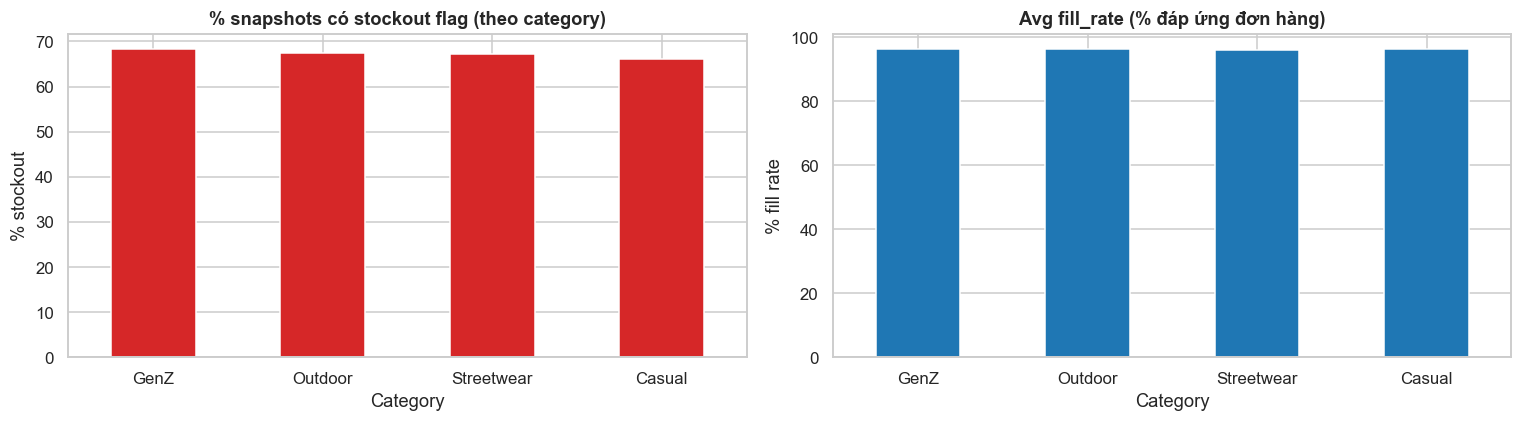

In [42]:
inv_cat = (inventory.groupby('category')
           .agg(avg_stockout_days=('stockout_days','mean'),
                pct_stockout=('stockout_flag','mean'),
                avg_fill_rate=('fill_rate','mean'),
                total_stockout_days=('stockout_days','sum'))
           .assign(pct_stockout=lambda d: d['pct_stockout']*100,
                   avg_fill_rate=lambda d: d['avg_fill_rate']*100)
           .sort_values('pct_stockout', ascending=False))
print('Stockout theo category:')
print(inv_cat.to_string())

inv_seg = (inventory.groupby('segment')
           .agg(avg_stockout_days=('stockout_days','mean'),
                pct_stockout=('stockout_flag','mean'),
                avg_fill_rate=('fill_rate','mean'))
           .assign(pct_stockout=lambda d: d['pct_stockout']*100,
                   avg_fill_rate=lambda d: d['avg_fill_rate']*100)
           .sort_values('pct_stockout', ascending=False))
print('\nStockout theo segment:')
print(inv_seg.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
inv_cat['pct_stockout'].plot.bar(ax=axes[0], color='#d62728')
axes[0].set_title('% snapshots có stockout flag (theo category)')
axes[0].set_ylabel('% stockout')
inv_cat['avg_fill_rate'].plot.bar(ax=axes[1], color='#1f77b4')
axes[1].set_title('Avg fill_rate (% đáp ứng đơn hàng)')
axes[1].set_ylabel('% fill rate')
for a in axes:
    a.set_xlabel('Category')
    a.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

### 🔍 7.3 Top SKU theo stockout severity

In [43]:
prod_inv = (inventory.groupby(['product_id','product_name','category'])
            .agg(total_stockout_days=('stockout_days','sum'),
                 n_snapshots_stockout=('stockout_flag','sum'),
                 avg_fill_rate=('fill_rate','mean'))
            .assign(avg_fill_rate=lambda d: d['avg_fill_rate']*100)
            .reset_index()
            .sort_values('total_stockout_days', ascending=False))

prod_inv = prod_inv.merge(prod_sold_qty, on='product_id', how='left').fillna({'units_sold':0})
print('Top 15 SKU theo total stockout days:')
print(prod_inv.head(15).to_string(index=False))

Top 15 SKU theo total stockout days:
 product_id      product_name   category  total_stockout_days  n_snapshots_stockout  avg_fill_rate  units_sold
       1009 HanoiStreet YY-10       GenZ                  215                    82          93.98   14,614.00
        907 HanoiStreet UE-16 Streetwear                  191                    70          93.99   18,378.00
        764 HanoiStreet RP-52    Outdoor                  185                    67          94.29   12,147.00
        939 HanoiStreet UC-02 Streetwear                  185                    55          91.67    7,545.00
        993 HanoiStreet UC-56 Streetwear                  181                    77          94.46   20,613.00
        791 HanoiStreet RP-79    Outdoor                  177                    77          94.68   41,716.00
        438  SaigonFlex UM-43 Streetwear                  174                    58          92.93   28,614.00
       2402  VietMotion YY-11       GenZ                  172              

### 🔮 7.4 Predictive — Lost revenue ước tính từ stockout

**Phép tính (xấp xỉ):** với mỗi sản phẩm, ước doanh thu/ngày trung bình khi còn stock = `tổng revenue / (tổng ngày trong catalog − stockout_days)`. Lost revenue = `daily_revenue × stockout_days`. Tổng lại trên catalog.

In [44]:
prod_rev = oi_valid.groupby('product_id').agg(
    revenue=('net_revenue','sum'),
    units_sold=('quantity','sum')
).reset_index()
prod_inv_months = inventory.groupby('product_id').agg(
    months_in_catalog=('snapshot_date','count'),
    total_stockout_days=('stockout_days','sum'),
).reset_index()
prod_loss = prod_rev.merge(prod_inv_months, on='product_id', how='inner')

prod_loss['available_days'] = prod_loss['months_in_catalog']*30 - prod_loss['total_stockout_days']
prod_loss['avg_daily_rev']  = np.where(prod_loss['available_days']>0,
                                        prod_loss['revenue']/prod_loss['available_days'], 0)
prod_loss['lost_revenue']   = prod_loss['avg_daily_rev'] * prod_loss['total_stockout_days']

total_lost = prod_loss['lost_revenue'].sum()
total_lost_per_year = total_lost / years_data
total_actual_rev = prod_loss['revenue'].sum()

print(f'Tổng lost revenue ước tính từ stockout: {total_lost/1e9:.2f}B VND')
print(f'  = {total_lost/total_actual_rev*100:.2f}% so với actual revenue ({total_actual_rev/1e9:.2f}B)')
print(f'  = {total_lost_per_year/1e9:.2f}B VND/năm trung bình')

top_loss_inv = (prod_loss.merge(products[['product_id','product_name','category']], on='product_id')
                .sort_values('lost_revenue', ascending=False)
                .head(10))
print(f'\nTop 10 SKU lost revenue cao nhất:')
print(top_loss_inv[['product_name','category','revenue','total_stockout_days','lost_revenue']].to_string(index=False))

Tổng lost revenue ước tính từ stockout: 0.64B VND
  = 4.47% so với actual revenue (14.23B)
  = 0.06B VND/năm trung bình

Top 10 SKU lost revenue cao nhất:
     product_name   category        revenue  total_stockout_days  lost_revenue
 SaigonFlex UM-43 Streetwear 295,557,917.65                  174 22,496,534.41
 SaigonFlex UM-92 Streetwear 346,762,171.85                   82 13,683,589.07
 SaigonFlex UM-96 Streetwear 218,785,266.44                  155  9,758,767.28
HanoiStreet UM-10 Streetwear 295,894,271.88                  110  8,868,765.64
 SaigonFlex UC-22 Streetwear  75,653,199.78                  104  8,317,053.68
 SaigonFlex UM-12 Streetwear 114,373,597.83                  100  7,676,080.39
HanoiStreet UE-16 Streetwear 119,635,295.35                  191  7,644,811.45
 SaigonFlex UM-14 Streetwear  63,271,049.64                   76  6,830,397.40
 SaigonFlex UM-80 Streetwear 231,760,820.59                   52  6,556,889.37
 SaigonFlex UC-69 Streetwear 181,192,900.07            

### 🎯 7.5 Prescriptive — Đề xuất hành động

In [45]:
top_stockout_cat = inv_cat.index[0]
top_stockout_pct = inv_cat.iloc[0]['pct_stockout']

saving_per_year_50 = total_lost_per_year * 0.5

recs7 = [
    {
        'rank': 1,
        'action': f'Reorder logic upgrade — đặc biệt cho category {top_stockout_cat} (stockout {top_stockout_pct:.1f}% snapshots)',
        'rationale': f'Total stockout days catalog: {total_stockout_days:,}, fill_rate TB chỉ {avg_fill_rate:.1f}%. Lost revenue ước {total_lost_per_year/1e9:.2f}B/năm',
        'estimated_impact': f'Giảm 50% stockout = +{saving_per_year_50/1e9:.2f}B VND/năm (recapture lost revenue)',
    },
    {
        'rank': 2,
        'action': f'Safety stock cao hơn cho top 20 SKU bị stockout nặng nhất',
        'rationale': 'Top SKU stockout days nhiều nhất ngậm phần lớn lost revenue. Tăng safety stock 1.5× → tăng carrying cost ít nhưng cứu được bán',
        'estimated_impact': f'Top 20 SKU loss recovery 70% = +{0.70 * top_loss_inv["lost_revenue"].sum() / years_data / 1e9:.2f}B/năm',
    },
    {
        'rank': 3,
        'action': 'Demand forecasting model (cho Phần 3) feed vào inventory replenishment',
        'rationale': 'Phần 3 đang build forecasting model — nếu tích hợp vào inventory planning, có thể proactive thay vì reactive',
        'estimated_impact': 'Cần đo sau khi triển khai (không quantify được trước)',
    },
]

recs7_df = pd.DataFrame(recs7)
print(recs7_df.to_string(index=False))

for r in recs7:
    RECOMMENDATIONS.append({'section': 'Inventory & Stockout', **r})

print(f'\n✅ Section 7 đóng góp {len(recs7)} đề xuất')

 rank                                                                        action                                                                                                                      rationale                                            estimated_impact
    1 Reorder logic upgrade — đặc biệt cho category GenZ (stockout 68.3% snapshots)                                        Total stockout days catalog: 69,925, fill_rate TB chỉ 96.1%. Lost revenue ước 0.06B/năm Giảm 50% stockout = +0.03B VND/năm (recapture lost revenue)
    2                     Safety stock cao hơn cho top 20 SKU bị stockout nặng nhất Top SKU stockout days nhiều nhất ngậm phần lớn lost revenue. Tăng safety stock 1.5× → tăng carrying cost ít nhưng cứu được bán                   Top 20 SKU loss recovery 70% = +0.01B/năm
    3        Demand forecasting model (cho Phần 3) feed vào inventory replenishment                   Phần 3 đang build forecasting model — nếu tích hợp vào inventory planning, có thể pro

---

## <a id='exec'></a>Executive Summary — Tổng hợp & Roadmap hành động

### Bối cảnh

Phân tích dữ liệu e-commerce thời trang VN giai đoạn 04/07/2012 – 31/12/2022 (3,833 ngày). Phát hiện business **đang tụt dốc 6 năm liên tục**: peak doanh thu 2016 (~2.10B VND/năm) → 2022 (1.17B, **−44% peak**). Chỉ 2022 mới có dấu hiệu hồi phục nhẹ (+12% YoY).

### Smoking guns (nguyên nhân gốc rễ)

1. **Retention sụp đổ.** Cohort signup 2012-2015 retain 31.1% năm 2; cohort 2018-2021 chỉ 19.5% — giảm ~37%. Toàn bộ tụt revenue đến từ returning customer (1.69B → 0.84B), không phải acquisition.

2. **Half catalog đang bán mà lỗ.** 791 SKU (50% catalog) margin <10%, đóng góp 57.7% revenue nhưng profit ÂM −0.24B. 412 ⭐ Stars (24% catalog) cứu cả công ty với +1.55B profit.

3. **West region champion bị bỏ rơi.** West LTV 0.23M/khách (cao nhất, gấp 1.5× East) nhưng chỉ 14.4K khách và đã tụt **−54% từ peak** — nhanh nhất trong 3 region. Mất khách West = mất khách giá trị nhất.

4. **Mùa vụ ngược kỳ vọng.** Q2 (T4-T6) là cao điểm (+51% lift), Q4 ÂM (−36%). Wednesday cao hơn weekend. Pattern phản chu kỳ B2C → khách hàng nhiều khả năng là dân văn phòng.

### Câu chuyện thống nhất

Cả 7 góc phân tích đều chỉ về **một chiến lược chung: tập trung RETENTION**. Acquisition không phải vấn đề (channel LTV bằng nhau, signup ổn định). Vấn đề là khách đến nhưng không quay lại, products half-catalog đang lỗ, region champion West đang chảy máu.

In [46]:
import re
def extract_impact_b(s):
    m = re.search(r'([+\-]?\d+(?:\.\d+)?)\s*B', str(s))
    return float(m.group(1)) if m else 0.0

df_all = pd.DataFrame(RECOMMENDATIONS)
df_all['impact_B'] = df_all['estimated_impact'].apply(extract_impact_b)
df_all = df_all.sort_values('impact_B', ascending=False).reset_index(drop=True)
df_all['priority'] = df_all.index + 1

print('='*100)
print('   ROADMAP HÀNH ĐỘNG — sắp xếp theo impact tài chính ước tính')
print('='*100)
print(df_all[['priority','section','action','estimated_impact']].to_string(index=False))
print('\n' + '='*100)

annual_recs = df_all[df_all['estimated_impact'].str.contains('năm', na=False)]
total_annual = annual_recs['impact_B'].sum()
print(f'Tổng đề xuất: {len(df_all)} từ 7 section')
print(f'Tổng impact ước tính (chỉ rec /năm): {total_annual:+.2f}B VND/năm')

   ROADMAP HÀNH ĐỘNG — sắp xếp theo impact tài chính ước tính
 priority                 section                                                                                                                  action                                                                                                estimated_impact
        1     Geography & Channel Học playbook West (LTV champion) áp dụng cho East/Central — analyze: vì sao khách West mua 10.6 đơn TB vs East 6.1 đơn?                                               +3.07B VND lifetime nếu các region khác đóng 50% LTV gap với West
        2        Revenue Dynamics                                            🚨 Root cause analysis cho tụt dốc 2016→2021 (−50% từ peak) trong Section 2-4 Recovery 50% gap = +0.47B VND/năm (sau khi xác định root cause: customer churn? category fatigue? competition?)
        3   Customer Segmentation            Retention program cho Champions (24,490 khách, đóng góp 64% revenue) — VIP perks, sớm phát hiện

### Top 5 ưu tiên hành động (90 ngày đầu)

1. **Retention program cho Champions** — VIP perks, churn-prevention. Champions = 28% khách → 64% revenue. Mất 1 Champion = 372K VND.
2. **Cứu West region** — root cause analysis vì sao West tụt 54%, kèm reactivation campaign region-specific.
3. **Cắt slow-mover SKU + push Stars** — tinh giảm 906 SKU đang ngậm carrying cost; tăng visibility 380 Stars.
4. **Kill promo losers** — A/B test trước khi rollout, KPI = net value chứ không phải gross sales.
5. **Fix size guide Streetwear** — wrong_size 35% returns. Quick win về cost.

### Limitations & caveats

- Lift analysis ở Section 5 dùng baseline ±30 ngày; promo overlap có thể nhiễu.
- Lost revenue stockout (Section 7) là xấp xỉ vì inventory là snapshot cuối tháng.
- ROI estimates giả định 1-1 các ngày tương đương — thực tế đòi hỏi A/B test.
- Tất cả "B VND impact" là ước tính ban đầu; cần measurement framework để đo thực tế khi triển khai.